# Ekstraksi Fitur TSFEL dan Perhitungan Manual pada Data Polutan Udara

Catatan ini adalah **bagian 1 dari 2** analisis data polutan udara Kecamatan Bangkalan menggunakan library **TSFEL** (*Time Series Feature Extraction Library*). Bagian ini mencakup persiapan data, ekstraksi 68 fitur time series (domain statistical, temporal, spectral, dan fractal) untuk tiga polutan, yaitu **NO2, SO2, dan CO**, serta konsep, rumus, dan pembuktian perhitungan manual untuk fitur bagian sendiri. Proses **K-Means Clustering** (pengambilan data kelas dari MySQL, reduksi dimensi PCA, analisis jumlah cluster dengan Silhouette Coefficient, scatter plot, peta hasil clustering, dan workflow KNIME) dibahas terpisah pada notebook **bagian 2**.

**Ketentuan data hasil ekstraksi:**
- Ketiga polutan digabung dalam **satu baris dengan 3 × 68 = 204 kolom**. Nama kolom berawalan nama polutan, misalnya `NO2_abs_energy`, `SO2_abs_energy`, dan `CO_abs_energy`.
- Ekstraksi dilakukan untuk **dua skenario interpolasi**, yaitu **linier** dan **polynomial** (orde 2), sehingga menghasilkan dua berkas: `All-Pollutants-Bangkalan-TSFEL-linear.csv` dan `All-Pollutants-Bangkalan-TSFEL-polynomial.csv`.

Cakupan catatan ini:
1. Data preparation: deteksi outlier (metode IQR) dan imputasi missing value untuk ketiga polutan, dengan skenario interpolasi linier dan polynomial
2. Ekstraksi 68 fitur TSFEL × 3 polutan = 204 kolom untuk tiap skenario
3. Konsep dasar, rumus, dan pembuktian perhitungan manual untuk fitur bagian sendiri (`fundamental_frequency`, `hist_mode`)
4. Deskripsi lengkap 68 fitur TSFEL berdasarkan 4 domain resmi (Statistical, Temporal, Spectral, Fractal)

## 1. Instalasi Library

In [1]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.8 MB/s eta 0:00:00


Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install tsfel` memasang pustaka `tsfel` (*Time Series Feature Extraction Library*), yang menyediakan kumpulan fungsi siap pakai untuk menghitung berbagai fitur statistik, spektral, temporal, dan fraktal dari sinyal deret waktu. Pustaka ini dipasang satu kali di awal karena dipakai berulang pada ketiga tahap ekstraksi (NO2, CO, SO2) berikutnya.

### 1.1 Pemeriksaan Berkas Data Kecamatan Bangkalan

Notebook ini membaca **`all_polutan_Bangkalan_timeseries.csv`**: deret waktu **harian**, satu baris per hari, dengan kolom tanggal (`tanggal` atau `date`) serta `CO`, `NO2`, dan `SO2`. Kolom lain seperti `HCHO`, `O3`, dan `CH4` boleh ada dan akan diabaikan. Nilai kosong boleh dibiarkan kosong (akan ditangani pada bagian 2). Sel berikut memeriksa berkas dan strukturnya sebelum proses lanjut; di Colab, berkas diminta diunggah bila belum ada.

In [2]:

from pathlib import Path
import pandas as pd

DATA_CSV = "all_polutan_Bangkalan_timeseries.csv"
POLUTAN_WAJIB = ["CO", "NO2", "SO2"]
NAMA_TANGGAL = ["tanggal", "date", "tgl", "datetime", "time", "waktu"]   # nama kolom tanggal yang dikenali


def muat_data(path=None):
    """Baca CSV, samakan nama kolom tanggal menjadi 'tanggal'. Kolom lain (HCHO, O3, CH4, dst.) dibiarkan."""
    d = pd.read_csv(path or DATA_CSV)
    asli = {c.strip().lower(): c for c in d.columns}
    kol_tgl = next((asli[n] for n in NAMA_TANGGAL if n in asli), None)
    if kol_tgl is None:
        raise ValueError(f"Kolom tanggal tidak ditemukan. Kolom di berkas: {list(d.columns)}")
    d = d.rename(columns={kol_tgl: "tanggal"})
    # nama polutan: terima huruf besar/kecil apa pun (co, no2, so2)
    peta = {c: c.upper() for c in d.columns if c.upper() in POLUTAN_WAJIB and c != c.upper()}
    d = d.rename(columns=peta)
    kurang = [k for k in POLUTAN_WAJIB if k not in d.columns]
    if kurang:
        raise ValueError(f"Kolom polutan tidak ada: {kurang}. Kolom di berkas: {list(d.columns)}")
    return d


if not Path(DATA_CSV).exists():                      # nama lain? cari *bangkalan*.csv (selain hasil ekstraksi)
    _kand = [p for p in Path(".").glob("*.csv")
             if "bangkalan" in p.name.lower() and not p.name.startswith("All-Pollutants")]
    if _kand:
        DATA_CSV = str(sorted(_kand, key=lambda p: -p.stat().st_mtime)[0])
        print("Memakai berkas:", DATA_CSV)
if not Path(DATA_CSV).exists():
    try:
        from google.colab import files
        print(f"Unggah {DATA_CSV}:")
        files.upload()
    except ImportError:
        pass
if not Path(DATA_CSV).exists():
    raise FileNotFoundError(f"{DATA_CSV} tidak ditemukan di {Path.cwd()}")

_cek = muat_data()
_cek["tanggal"] = pd.to_datetime(_cek["tanggal"])
print("Kolom di berkas :", list(pd.read_csv(DATA_CSV, nrows=0).columns))
print("Kolom dipakai   : tanggal +", POLUTAN_WAJIB, "(kolom lain diabaikan)")
print(f"Baris: {len(_cek)} | rentang: {_cek['tanggal'].min().date()} s.d. {_cek['tanggal'].max().date()}")
print("Tanggal ganda :", int(_cek["tanggal"].duplicated().sum()))
hari_hilang = pd.date_range(_cek["tanggal"].min(), _cek["tanggal"].max()).difference(_cek["tanggal"])
print("Hari yang tidak ada barisnya:", len(hari_hilang))
display(_cek[["tanggal"] + POLUTAN_WAJIB].describe().T)


Kolom di berkas : ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']
Kolom dipakai   : tanggal + ['CO', 'NO2', 'SO2'] (kolom lain diabaikan)
Baris: 367 | rentang: 2025-08-29 s.d. 2026-08-30
Tanggal ganda : 0
Hari yang tidak ada barisnya: 0


,count,mean,min,25%,50%,75%,max,std
tanggal,367,2026-02-28 00:00:00,2025-08-29 00:00:00,2025-11-28 12:00:00,2026-02-28 00:00:00,2026-05-30 12:00:00,2026-08-30 00:00:00,NaN
CO,279.0,0.028658,0.020487,0.026678,0.028363,0.030174,0.043208,0.002864
NO2,293.0,0.000025,0.000004,0.000019,0.000024,0.00003,0.000109,0.000011
SO2,314.0,0.000037,-0.000862,-0.000014,0.000034,0.000097,0.000381,0.000125


## 2. Data Preparation: Deteksi Outlier dan Imputasi Missing Value

Sebelum sinyal CO, NO2, dan SO2 dimasukkan ke proses ekstraksi fitur, ketiganya perlu dibersihkan dulu dari outlier dan nilai kosong, karena TSFEL tidak bisa mengolah data yang masih mengandung `NaN`. Tahap ini sengaja dipisahkan dari proses ekstraksi fitur (bagian 3) agar alurnya lebih jelas: bersihkan dulu ketiga polutan sekaligus di sini, baru masuk ke ekstraksi fitur gabungan 204 kolom pada bagian 3.

Alur pembersihan pada tiap polutan mengikuti tiga langkah yang sama:
1. **Paksa numerik** — kolom polutan dipaksa bertipe numerik (`pd.to_numeric(..., errors="coerce")`); nilai yang tidak valid otomatis menjadi `NaN`.
2. **Deteksi outlier (metode IQR)** — nilai di luar rentang `[Q1 - 1,5×IQR, Q3 + 1,5×IQR]` ditandai sebagai outlier, lalu diubah menjadi `NaN` (bukan dihapus barisnya) agar deret tanggal tetap utuh dan ikut ditangani pada langkah imputasi.
3. **Imputasi berbasis waktu** — nilai kosong diisi dengan `interpolate(method="time")` (**skenario linier**, bagian 2 ini), lalu sisa nilai kosong di ujung awal/akhir data (yang tidak bisa diinterpolasi) diisi dengan `ffill()` dan `bfill()`. Skenario kedua, **polynomial**, ditambahkan pada bagian 2.5.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POLUTAN_TARGET = ["CO", "NO2", "SO2"]

df = muat_data()
df["tanggal"] = pd.to_datetime(df["tanggal"])
df = df.sort_values("tanggal").reset_index(drop=True)

# Menyimpan data asli (sebelum penanganan) untuk keperluan perbandingan/visualisasi
df_awal = df.copy()

sinyal_bersih = {}
ringkasan_missing_list = []
batas_iqr = {}
outliers_iqr_dict = {}

for pol in POLUTAN_TARGET:
    df[pol] = pd.to_numeric(df[pol], errors="coerce")

    # Missing value pada data awal (sebelum outlier ditangani)
    n_missing_awal = df[pol].isna().sum()
    persen_missing_awal = (n_missing_awal / len(df)) * 100

    # Deteksi outlier dengan metode IQR
    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    kondisi_outlier = (df[pol] < lower) | (df[pol] > upper)
    outliers_iqr_dict[pol] = df.loc[kondisi_outlier, ["tanggal", pol]].copy()
    jumlah_outlier = kondisi_outlier.sum()
    batas_iqr[pol] = {"lower": lower, "upper": upper}

    # Outlier dijadikan NaN agar ikut ditangani pada tahap imputasi
    df.loc[kondisi_outlier, pol] = np.nan

    # Missing value setelah deteksi outlier
    n_missing_setelah_outlier = df[pol].isna().sum()
    persen_missing_setelah_outlier = (n_missing_setelah_outlier / len(df)) * 100

    # Imputasi berdasarkan waktu (time-based interpolation), sisa di ujung data diisi ffill/bfill
    hasil_interpolasi = (
        df.set_index("tanggal")[[pol]]
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    n_missing_sesudah = hasil_interpolasi[pol].isna().sum()
    sinyal_bersih[pol] = hasil_interpolasi[pol].astype(float).values

    ringkasan_missing_list.append({
        "polutan": pol,
        "missing_awal": n_missing_awal,
        "persen_awal": persen_missing_awal,
        "jumlah_outlier": jumlah_outlier,
        "missing_setelah_outlier": n_missing_setelah_outlier,
        "persen_setelah_outlier": persen_missing_setelah_outlier,
        "missing_sesudah_imputasi": n_missing_sesudah,
    })

    print(f"\n===== {pol} =====")
    print(f"Missing value awal               : {n_missing_awal} ({persen_missing_awal:.2f}%)")
    print(f"Jumlah outlier (IQR)              : {jumlah_outlier}")
    print(f"Missing setelah deteksi outlier    : {n_missing_setelah_outlier} ({persen_missing_setelah_outlier:.2f}%)")
    print(f"Missing setelah imputasi           : {n_missing_sesudah} ({(n_missing_sesudah/len(df))*100:.2f}%)")

# Data hasil penanganan lengkap, dengan kolom tanggal yang tetap sama seperti data asli
df_setelah = df_awal.copy()
for pol in POLUTAN_TARGET:
    df_setelah[pol] = sinyal_bersih[pol]

print("\nPreprocessing selesai untuk:", POLUTAN_TARGET)


===== CO =====
Missing value awal               : 88 (23.98%)
Jumlah outlier (IQR)              : 7
Missing setelah deteksi outlier    : 95 (25.89%)
Missing setelah imputasi           : 0 (0.00%)

===== NO2 =====
Missing value awal               : 74 (20.16%)
Jumlah outlier (IQR)              : 8
Missing setelah deteksi outlier    : 82 (22.34%)
Missing setelah imputasi           : 0 (0.00%)

===== SO2 =====
Missing value awal               : 53 (14.44%)
Jumlah outlier (IQR)              : 25
Missing setelah deteksi outlier    : 78 (21.25%)
Missing setelah imputasi           : 0 (0.00%)

Preprocessing selesai untuk: ['CO', 'NO2', 'SO2']


Penjelasan kode di atas adalah sebagai berikut.

- `all_polutan_Bangkalan_timeseries.csv` dibaca, kolom `tanggal` dijadikan datetime dan diurutkan; `df_awal` menyimpan kondisi sebelum penanganan sebagai pembanding.
- Untuk tiap polutan (CO, NO2, SO2) dijalankan tiga langkah berurutan: paksa numerik → deteksi outlier (IQR) → imputasi berbasis waktu.
- `n_missing_awal` dihitung sebelum deteksi outlier, `n_missing_setelah_outlier` sesudahnya, sehingga selisihnya menunjukkan jumlah outlier yang diubah menjadi `NaN`.
- Batas IQR dan daftar outlier disimpan per polutan untuk dipakai ulang pada visualisasi (2.2) tanpa hitung ulang.
- `sinyal_bersih` (satu nilai per hari untuk tiap polutan, tanpa missing value) menjadi acuan sinyal bersih; langkah pembersihan yang sama diterapkan kembali pada kode ekstraksi fitur (bagian 3) dan pada perhitungan manual (bagian 4).
- `df_setelah` menggabungkan hasil bersih ketiga polutan untuk visualisasi pada bagian 2.3.

### 2.1 Ringkasan Missing Value Sebelum dan Sesudah Penanganan

In [4]:
ringkasan_missing = pd.DataFrame(ringkasan_missing_list)
display(ringkasan_missing)

,polutan,missing_awal,persen_awal,jumlah_outlier,missing_setelah_outlier,persen_setelah_outlier,missing_sesudah_imputasi
0,CO,88,23.978202,7,95,25.885559,0
1,NO2,74,20.163488,8,82,22.343324,0
2,SO2,53,14.441417,25,78,21.253406,0


Penjelasan kode di atas adalah sebagai berikut.

- `ringkasan_missing_list` (diisi pada perulangan bagian 2) diubah menjadi `DataFrame` agar jumlah missing value dan outlier tiap polutan bisa dilihat dalam satu tabel.
- Tabel ini merangkum tiga tahap: `missing_awal` (sebelum outlier ditangani), `missing_setelah_outlier` (setelah outlier diubah menjadi `NaN`, sehingga jumlahnya sedikit lebih besar dari `missing_awal`), dan `missing_sesudah_imputasi` (selalu 0 untuk ketiga polutan, karena `interpolate` + `ffill`/`bfill` mengisi seluruh nilai kosong).
- Bandingkan kolom `jumlah_outlier` antar polutan: polutan dengan outlier terbanyak mengalami kenaikan `missing_setelah_outlier` paling besar dibanding `missing_awal`, karena tiap outlier diubah menjadi `NaN`. Angkanya bergantung pada data Kecamatan Bangkalan, lihat tabel di atas.

### 2.2 Perbandingan Data Sebelum dan Sesudah Deteksi Outlier

Kode berikut membandingkan data tiap polutan sebelum dan sesudah nilai outlier ditangani. Grafik "sebelum" menampilkan nilai outlier yang ditandai (titik merah) beserta batas bawah/atas IQR, sedangkan grafik "sesudah" menunjukkan data setelah outlier diubah menjadi `NaN` (garis terputus pada titik outlier).

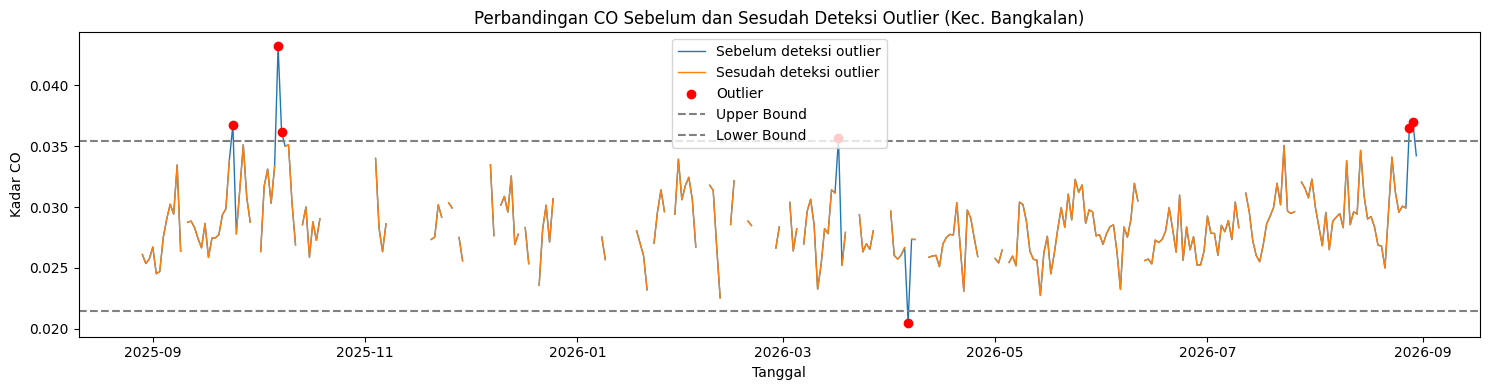

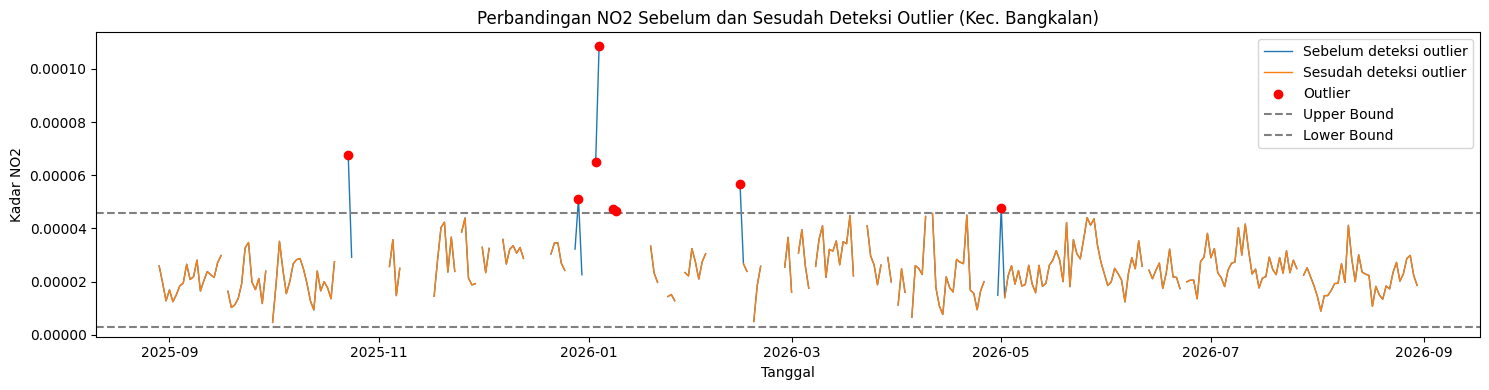

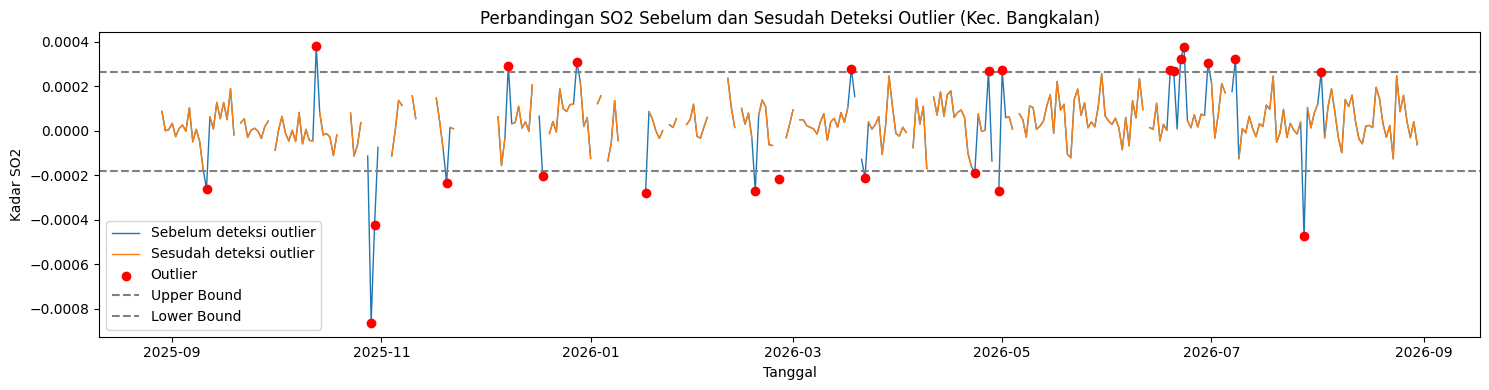

In [5]:
for pol in POLUTAN_TARGET:
    data_sebelum = df_awal.copy()
    data_sebelum[pol] = pd.to_numeric(data_sebelum[pol], errors="coerce")

    lower_bound = batas_iqr[pol]["lower"]
    upper_bound = batas_iqr[pol]["upper"]

    kondisi_outlier = (
        (data_sebelum[pol] < lower_bound) |
        (data_sebelum[pol] > upper_bound)
    )

    data_setelah = data_sebelum.copy()
    data_setelah.loc[kondisi_outlier, pol] = np.nan

    plt.figure(figsize=(15, 4))
    plt.plot(data_sebelum["tanggal"], data_sebelum[pol], label="Sebelum deteksi outlier", linewidth=1)
    plt.plot(data_setelah["tanggal"], data_setelah[pol], label="Sesudah deteksi outlier", linewidth=1)
    plt.scatter(
        data_sebelum.loc[kondisi_outlier, "tanggal"],
        data_sebelum.loc[kondisi_outlier, pol],
        label="Outlier", marker="o", color="red", zorder=5
    )
    plt.axhline(upper_bound, linestyle="dashed", color="gray", label="Upper Bound")
    plt.axhline(lower_bound, linestyle="dashed", color="gray", label="Lower Bound")
    plt.title(f"Perbandingan {pol} Sebelum dan Sesudah Deteksi Outlier (Kec. Bangkalan)")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Perulangan dilakukan untuk CO, NO2, dan SO2 agar ketiga polutan divisualisasikan dengan cara yang sama.
- `batas_iqr[pol]` (disimpan pada bagian 2) dipakai langsung sebagai batas bawah/atas pada grafik, tanpa menghitung ulang IQR.
- Titik merah menandai nilai yang terdeteksi sebagai outlier; setelah diubah menjadi `NaN`, titik tersebut terlihat sebagai celah pada garis "Sesudah deteksi outlier".
- Jumlah titik merah pada tiap grafik sama dengan `jumlah_outlier` pada tabel bagian 2.1; grafik dengan titik merah terbanyak adalah polutan yang paling banyak mengandung outlier.

### 2.3 Visualisasi Data Sesudah Imputasi

Kode berikut memvisualisasikan data setelah imputasi (`df_setelah`, hasil akhir dari bagian 2). Tanggal tetap menggunakan tanggal asli, dan tidak ada lagi celah kosong pada garisnya karena seluruh nilai `NaN` (baik missing asli maupun bekas outlier) sudah terisi.

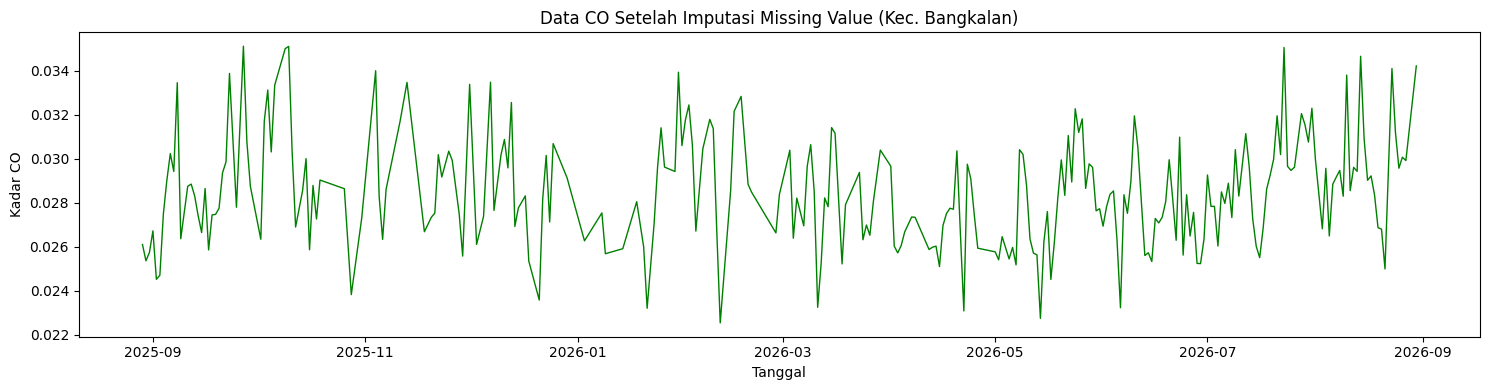

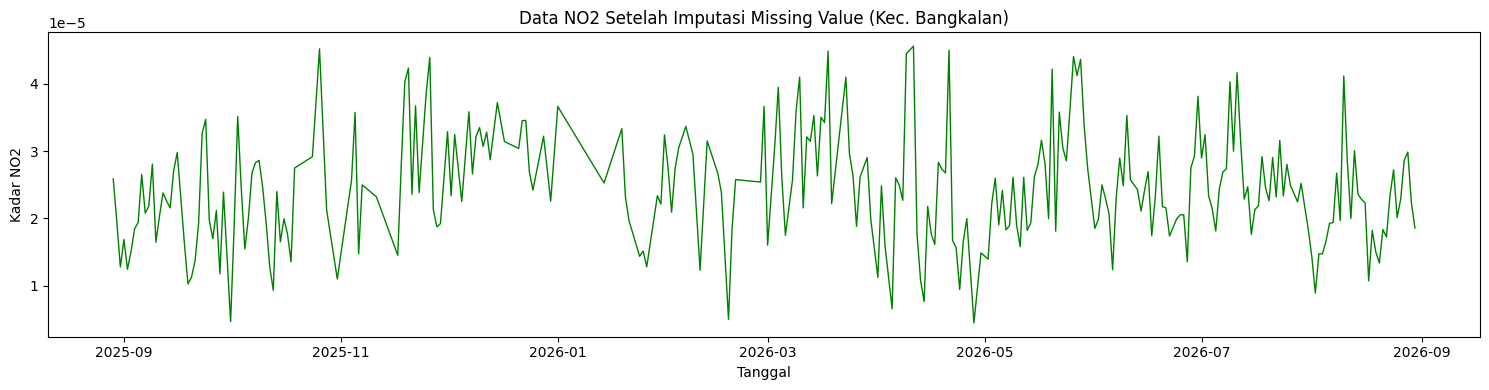

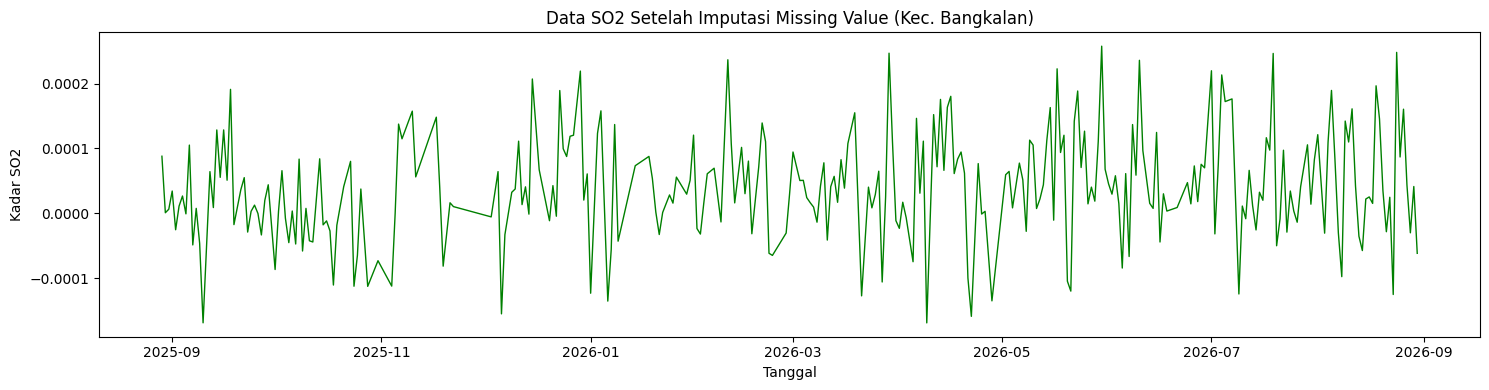

In [6]:
for pol in POLUTAN_TARGET:
    data_sesudah = df_setelah.copy()

    plt.figure(figsize=(15, 4))
    plt.plot(data_sesudah["tanggal"], data_sesudah[pol], linewidth=1, color="green")
    plt.title(f"Data {pol} Setelah Imputasi Missing Value (Kec. Bangkalan)")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.tight_layout()
    plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- Perulangan menampilkan data CO, NO2, dan SO2 dari `df_setelah`, yaitu data gabungan (`df_awal` + `sinyal_bersih`) yang sudah melewati deteksi outlier dan imputasi pada bagian 2.
- Kolom `tanggal` tetap memakai tanggal asli sehingga visualisasi tetap mengikuti urutan waktu yang benar (sesuai rentang tanggal pada `all_polutan_Bangkalan_timeseries.csv`).
- Dibandingkan grafik "sebelum" pada bagian 2.2, garis pada bagian ini sudah kontinu tanpa celah — inilah sinyal bersih (`sinyal_bersih[pol]`); langkah pembersihan yang sama diterapkan pada ekstraksi 68 fitur (bagian 3) maupun perhitungan manual `hist_mode` dan `fundamental_frequency` (bagian 4).

### 2.4 Perbandingan Missing Value Antar Tahap Preprocessing

Tabel dan diagram batang berikut membandingkan jumlah missing value pada data awal, setelah deteksi outlier, dan setelah imputasi, untuk ketiga polutan sekaligus.

,polutan,missing_awal,missing_setelah_outlier,missing_sesudah_imputasi
0,CO,88,95,0
1,NO2,74,82,0
2,SO2,53,78,0


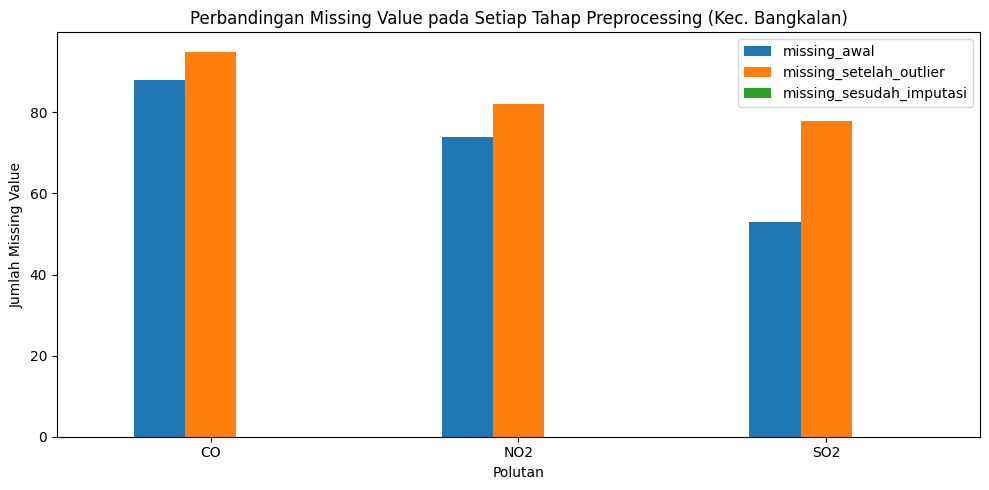

In [7]:
kolom_tahap_missing = [
    "missing_awal",
    "missing_setelah_outlier",
    "missing_sesudah_imputasi"
]

tabel_missing = ringkasan_missing[["polutan"] + kolom_tahap_missing].copy()
display(tabel_missing)

tabel_missing_plot = tabel_missing.set_index("polutan")
tabel_missing_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Missing Value pada Setiap Tahap Preprocessing (Kec. Bangkalan)")
plt.xlabel("Polutan")
plt.ylabel("Jumlah Missing Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- `tabel_missing` mengambil jumlah missing value pada tiga tahap (sebelum preprocessing, setelah outlier diubah menjadi `NaN`, dan setelah imputasi) untuk CO, NO2, dan SO2.
- Diagram batang memvisualisasikan data yang sama, sehingga penurunan jumlah missing value pada setiap tahap lebih mudah dibandingkan antar polutan. Batang "missing_sesudah_imputasi" pada ketiga polutan seharusnya nol, karena seluruh nilai kosong terisi oleh interpolasi dan `ffill`/`bfill`.
- Data bersih dari bagian ini (`sinyal_bersih`) menjadi acuan; langkah pembersihannya diterapkan kembali pada tahap ekstraksi fitur di bagian 3.

### 2.5 Skenario Interpolasi: Linier vs Polynomial

Sesuai instruksi tugas, imputasi dilakukan dengan **dua skenario**:
1. **Linier** — `interpolate(method="time")`, yaitu skenario pada bagian 2 di atas (`sinyal_bersih`).
2. **Polynomial** — `interpolate(method="polynomial", order=2)` (orde 2, sesuai ketentuan tugas; ubah `ORDE_POLINOMIAL` bila ketentuannya berbeda).

Outlier tetap dideteksi dengan batas IQR yang sama (`batas_iqr`), sehingga **satu-satunya perbedaan** antara kedua skenario adalah cara mengisi nilai kosong. Setelah interpolasi, sisa nilai kosong di ujung awal/akhir data diisi `ffill()` dan `bfill()`.

,polutan,skenario,N,min,maks,rata_rata,di_luar_batas_IQR
0,CO,linear,367,0.022542,0.035113,0.028467,0
1,CO,polynomial,367,0.021661,0.036402,0.028511,1
2,NO2,linear,367,0.000004,0.000046,0.000025,0
3,NO2,polynomial,367,0.000003,0.000056,0.000025,5
4,SO2,linear,367,-0.000169,0.000258,0.000036,0
5,SO2,polynomial,367,-0.000187,0.000258,0.000031,1


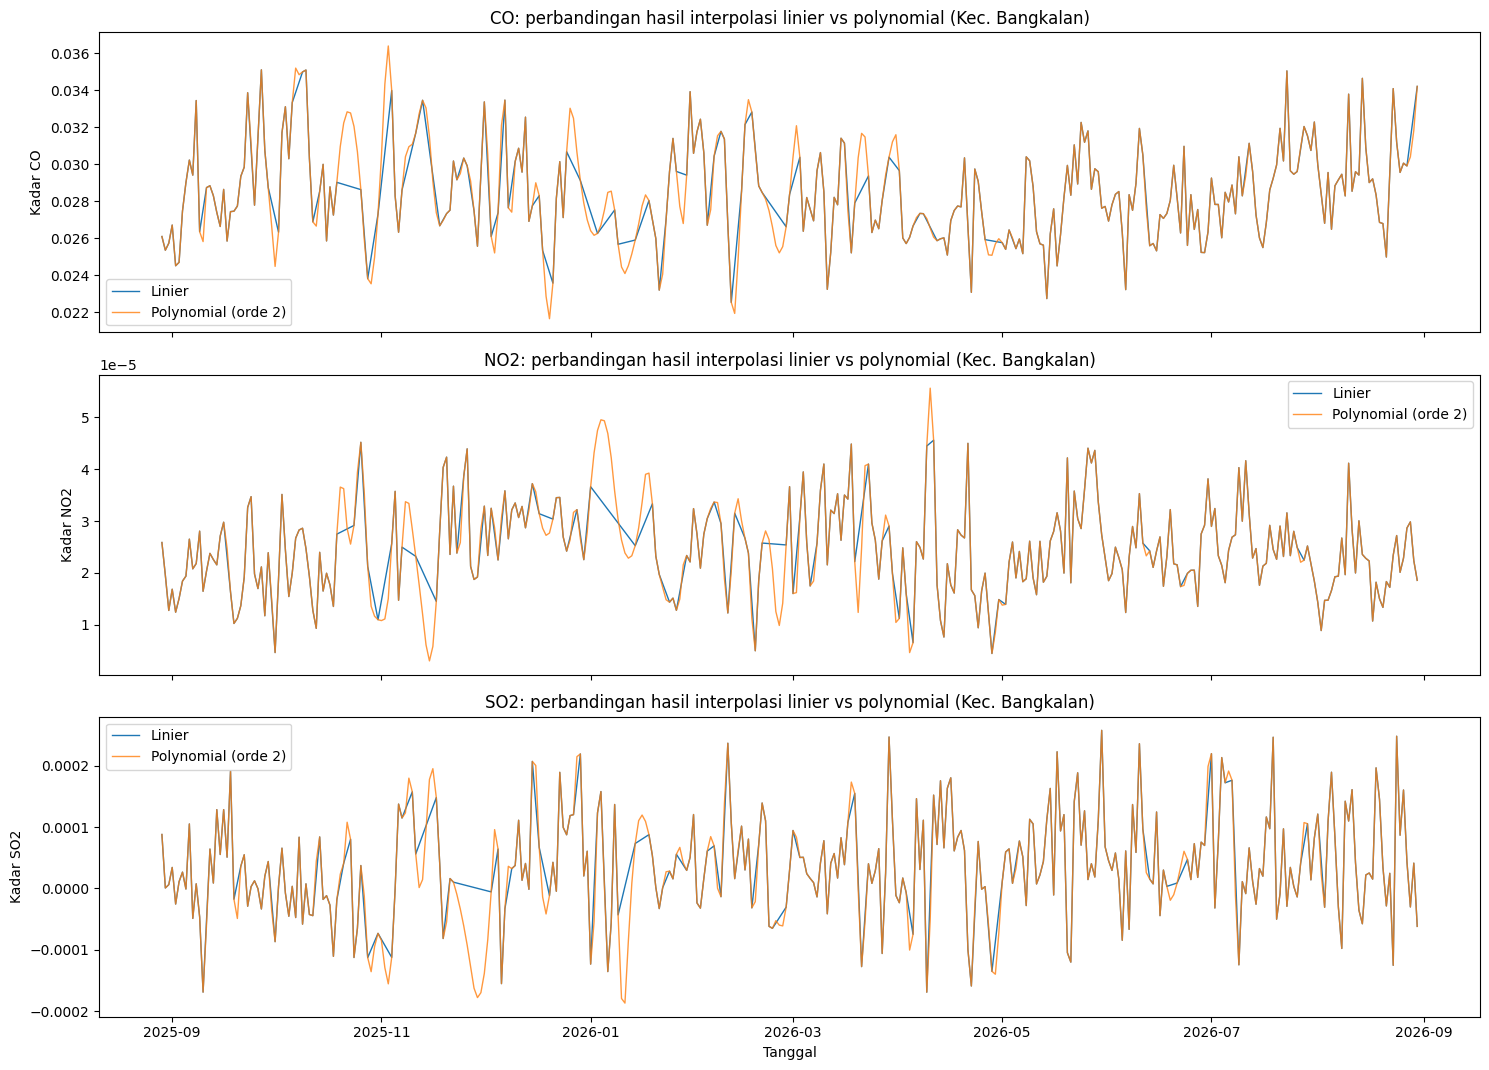

In [8]:
ORDE_POLINOMIAL = 2   # sesuaikan dengan ketentuan tugas
SKENARIO = ["linear", "polynomial"]

def siapkan_sinyal(pol, skenario):
    """Outlier IQR -> NaN -> interpolasi sesuai skenario -> ffill/bfill. Mengembalikan array 1D float."""
    s = pd.to_numeric(df_awal[pol], errors="coerce")
    b = batas_iqr[pol]
    s = s.mask((s < b["lower"]) | (s > b["upper"]))
    if skenario == "linear":
        s.index = df_awal["tanggal"]
        hasil = s.interpolate(method="time")
    else:
        # indeks integer agar interpolasi polynomial berjalan benar
        s = s.reset_index(drop=True)
        hasil = s.interpolate(method="polynomial", order=ORDE_POLINOMIAL)
    return hasil.ffill().bfill().astype(float).values

sinyal_skenario = {sk: {pol: siapkan_sinyal(pol, sk) for pol in POLUTAN_TARGET} for sk in SKENARIO}

# Verifikasi: skenario linier harus identik dengan sinyal_bersih pada bagian 2
for pol in POLUTAN_TARGET:
    assert np.allclose(sinyal_skenario["linear"][pol], sinyal_bersih[pol]), f"Linier {pol} tidak cocok dengan bagian 2"
    for sk in SKENARIO:
        assert not np.isnan(sinyal_skenario[sk][pol]).any(), f"Masih ada NaN pada {pol} ({sk})"

ringkas = []
for pol in POLUTAN_TARGET:
    for sk in SKENARIO:
        x = sinyal_skenario[sk][pol]
        ringkas.append({"polutan": pol, "skenario": sk, "N": len(x), "min": x.min(), "maks": x.max(), "rata_rata": x.mean(),
                        "di_luar_batas_IQR": int(((x < batas_iqr[pol]["lower"]) | (x > batas_iqr[pol]["upper"])).sum())})
display(pd.DataFrame(ringkas))

fig, axes = plt.subplots(len(POLUTAN_TARGET), 1, figsize=(15, 3.6 * len(POLUTAN_TARGET)), sharex=True)
for ax, pol in zip(axes, POLUTAN_TARGET):
    ax.plot(df_awal["tanggal"], sinyal_skenario["linear"][pol], label="Linier", linewidth=1)
    ax.plot(df_awal["tanggal"], sinyal_skenario["polynomial"][pol], label=f"Polynomial (orde {ORDE_POLINOMIAL})", linewidth=1, alpha=0.8)
    ax.set_title(f"{pol}: perbandingan hasil interpolasi linier vs polynomial (Kec. Bangkalan)")
    ax.set_ylabel(f"Kadar {pol}")
    ax.legend()
axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- `siapkan_sinyal()` memakai ulang `df_awal` dan `batas_iqr` dari bagian 2, sehingga outlier yang ditandai **sama persis** untuk kedua skenario; hanya metode `interpolate` yang berbeda (`method="time"` untuk linier, `method="polynomial", order=2` untuk polynomial).
- Pada skenario polynomial indeks diubah menjadi bilangan bulat (`reset_index`) karena `interpolate(method="polynomial")` membutuhkan indeks numerik; data berfrekuensi harian sehingga jarak antar titik tetap seragam.
- Interpolasi polynomial tidak mengisi nilai kosong di ujung awal/akhir deret, sehingga sisanya diisi `ffill()` dan `bfill()` — langkah yang sama dengan skenario linier.
- Tiga pengecekan otomatis: skenario linier harus identik dengan `sinyal_bersih` (bagian 2), tidak boleh ada `NaN` tersisa, dan kolom `di_luar_batas_IQR` pada tabel menunjukkan apakah interpolasi polynomial menghasilkan nilai di luar batas IQR (polynomial dapat *overshoot* di sela data yang jarang).
- Grafik menampilkan kedua hasil interpolasi pada satu sumbu untuk tiap polutan; perbedaan bentuk kurva inilah yang nanti membuat fitur TSFEL kedua skenario berbeda.
- `sinyal_skenario` (dua skenario × tiga polutan, masing-masing satu nilai per hari) menggambarkan sinyal yang diolah pada ekstraksi di bagian 3; kode ekstraksi menjalankan langkah interpolasi yang sama secara mandiri.

## 3. Ekstraksi 68 Fitur TSFEL × 3 Polutan = 204 Kolom (Linier dan Polynomial)

Ketiga polutan **digabung dalam satu baris**. Untuk tiap skenario interpolasi (linier dan polynomial), 68 fitur TSFEL dihitung pada sinyal NO2, SO2, dan CO, lalu nama kolomnya diberi awalan polutan:

$$3 \text{ polutan} \times 68 \text{ fitur} = 204 \text{ kolom}$$

Berkas hasilnya adalah `All-Pollutants-Bangkalan-TSFEL-linear.csv` dan `All-Pollutants-Bangkalan-TSFEL-polynomial.csv` (masing-masing 1 baris, 204 kolom). Sel kode di bawah berdiri sendiri: membaca `all_polutan_Bangkalan_timeseries.csv`, membersihkan outlier, melakukan interpolasi sesuai skenario, mengekstraksi 68 fitur tiap polutan, lalu menyimpan hasilnya.

In [9]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
df = muat_data()

df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

ORDE_POLINOMIAL = 2  # sesuaikan dengan ketentuan tugas
SKENARIO = ['linear', 'polynomial']

# ---------- 2. Daftar PERSIS 68 fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


def interpolasi(df_poly, pollutant, skenario):
    """Interpolasi sesuai skenario, mengembalikan array 1D float."""
    if skenario == 'linear':
        hasil = (
            df_poly.set_index('tanggal')[[pollutant]]
            .interpolate(method='time')
            .ffill()
            .bfill()
        )
    else:
        # Indeks integer agar interpolasi polynomial berjalan benar
        tmp = df_poly[['tanggal', pollutant]].reset_index(drop=True)
        tmp[pollutant] = (
            tmp[pollutant]
            .interpolate(method='polynomial', order=ORDE_POLINOMIAL)
            .ffill()
            .bfill()
        )
        hasil = tmp.set_index('tanggal')
    return hasil[pollutant].astype(float).values


# ---------- 3. Looping per skenario dan per polutan ----------
for skenario in SKENARIO:
    print(f"\n===== Skenario: {skenario} =====")
    combined_row = {}

    for pollutant in pollutants:
        print(f"\n--- Memproses polutan: {pollutant} ---")

        df_poly = df[['tanggal', pollutant]].copy()

        # Paksa kolom target jadi numerik
        df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')
        n_missing_before = df_poly[pollutant].isna().sum()
        print(f"Jumlah NaN/non-numerik pada {pollutant}: {n_missing_before}")

        # Handling outlier dengan IQR
        Q1 = df_poly[pollutant].quantile(0.25)
        Q3 = df_poly[pollutant].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_poly.loc[
            (df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound),
            pollutant
        ] = np.nan

        # Interpolasi sesuai skenario
        signal_1d = interpolasi(df_poly, pollutant, skenario)

        # Ekstraksi fitur dengan prefix nama polutan (misal: NO2_abs_energy)
        for fn_name in FEATURE_LIST:
            combined_row[f"{pollutant}_{fn_name}"] = extract_one(fn_name, signal_1d, fs)

    # ---------- 4. Simpan per skenario (1 baris, 204 kolom) ----------
    hasil_df = pd.DataFrame([combined_row])
    print(f"\nBerhasil! Total kolom akhir ({skenario}): {hasil_df.shape[1]}")

    output_filename = f'All-Pollutants-Bangkalan-TSFEL-{skenario}.csv'
    hasil_df.to_csv(output_filename, index=False)
    print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

===== Skenario: linear =====

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 74

--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 53

--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 88

Berhasil! Total kolom akhir (linear): 204
File berhasil disimpan sebagai: All-Pollutants-Bangkalan-TSFEL-linear.csv

===== Skenario: polynomial =====

--- Memproses polutan: NO2 ---
Jumlah NaN/non-numerik pada NO2: 74

--- Memproses polutan: SO2 ---
Jumlah NaN/non-numerik pada SO2: 53

--- Memproses polutan: CO ---
Jumlah NaN/non-numerik pada CO: 88

Berhasil! Total kolom akhir (polynomial): 204
File berhasil disimpan sebagai: All-Pollutants-Bangkalan-TSFEL-polynomial.csv


Penjelasan kode di atas adalah sebagai berikut.

- **Pengaturan.** `pollutants` menentukan urutan tiga blok kolom pada berkas hasil (NO2, SO2, CO), `fs = 1` berarti satu observasi per hari, `ORDE_POLINOMIAL = 2` adalah orde interpolasi polynomial, dan `SKENARIO` berisi dua skenario yang dijalankan.
- **Data masukan.** `all_polutan_Bangkalan_timeseries.csv` berisi seluruh polutan dalam satu berkas; kolom `tanggal` dijadikan datetime dan diurutkan agar interpolasi berbasis waktu berjalan benar.
- **Daftar fitur.** `FEATURE_LIST` memuat 68 nama fitur TSFEL, sehingga keluaran awal menampilkan 68 fitur per polutan dan 204 fitur secara keseluruhan.
- **Fungsi bantu.** `extract_one()` memanggil tiap fitur secara generik lewat `inspect.signature` (mendeteksi apakah fungsi membutuhkan parameter `fs`). `to_scalar()` merata-ratakan fitur yang aslinya menghasilkan banyak nilai (misalnya `mfcc`, `ecdf`, dan `wavelet_*`) agar tetap menjadi satu kolom.
- **Interpolasi.** `interpolasi()` mengisi `NaN` sesuai skenario: `interpolate(method="time")` untuk **linier** dan `interpolate(method="polynomial", order=2)` untuk **polynomial**. Sisa `NaN` di ujung data diisi `ffill()` dan `bfill()`. Pada skenario polynomial, indeks diubah menjadi bilangan bulat agar interpolasi berjalan benar.
- **Perulangan.** Untuk tiap skenario dan tiap polutan, kolom dipaksa numerik, jumlah `NaN` awal dicatat, lalu nilai di luar `[Q1 − 1,5×IQR, Q3 + 1,5×IQR]` diubah menjadi `NaN` (barisnya tidak dihapus agar deret tanggal tetap utuh). Sinyal kemudian diinterpolasi dan 68 fiturnya dihitung.
- **Keluaran.** Fitur dari ketiga polutan ditulis ke satu `combined_row` dengan nama kolom `<POLUTAN>_<fitur>`, diubah menjadi `DataFrame` **1 baris × 204 kolom**, dan disimpan ke `All-Pollutants-Bangkalan-TSFEL-<skenario>.csv`. Keluaran sel menunjukkan kedua skenario menghasilkan 204 kolom.

### 3.1 Membaca dan Memverifikasi Hasil Ekstraksi Gabungan

In [10]:
import re

daftar_hasil = {}
for skenario in SKENARIO:
    nama_file = f"All-Pollutants-Bangkalan-TSFEL-{skenario}.csv"
    daftar_hasil[skenario] = pd.read_csv(nama_file)
    h = daftar_hasil[skenario]
    kolom_fitur = list(h.columns)
    per_polutan = {p: sum(c.startswith(p + "_") for c in kolom_fitur) for p in pollutants}
    print(f"[{skenario}] ukuran data: {h.shape} | kolom fitur: {len(kolom_fitur)} | per polutan: {per_polutan}")
    display(h[kolom_fitur].iloc[:, :6])

# Bandingkan kedua skenario: berapa kolom yang nilainya berbeda?
a = daftar_hasil["linear"].select_dtypes("number")
b = daftar_hasil["polynomial"].select_dtypes("number")
beda = ~np.isclose(a.iloc[0].values, b.iloc[0].values, equal_nan=True)
print(f"\nKolom yang nilainya berbeda antara linier dan polynomial: {beda.sum()} dari {len(beda)}")

[linear] ukuran data: (1, 204) | kolom fitur: 204 | per polutan: {'NO2': 68, 'SO2': 68, 'CO': 68}


,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid,NO2_calc_max
0,2.465829e-07,0.00903,2.0,6.737239e-10,182.404884,0.000046


[polynomial] ukuran data: (1, 204) | kolom fitur: 204 | per polutan: {'NO2': 68, 'SO2': 68, 'CO': 68}


,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid,NO2_calc_max
0,2.526439e-07,0.00901,2.0,6.902838e-10,180.660363,0.000056



Kolom yang nilainya berbeda antara linier dan polynomial: 160 dari 204


Penjelasan kode di atas adalah sebagai berikut.

- Kedua berkas hasil dibaca ulang dari disk (bukan memakai variabel di memori) untuk memastikan isi berkas yang akan diunggah sudah benar.
- Untuk tiap skenario dicek ukuran data (harus `(1, 204)`) dan jumlah kolom per polutan (harus 68 untuk `NO2`, `SO2`, dan `CO`).
- `display(...)` menampilkan 6 kolom pertama sebagai pengecekan visual.
- Perbandingan antar skenario menghitung berapa kolom yang nilainya berbeda; skenario linier dan polynomial hanya berbeda pada cara imputasi, sehingga sebagian besar fitur berubah nilainya, tetapi fitur yang tidak bergantung pada nilai hasil imputasi (misalnya `calc_max` bila titik maksimum adalah data asli) bisa tetap sama.

### 3.2 Ringkasan Ekstraksi Gabungan

In [11]:
ringkasan = pd.DataFrame({
    "skenario": SKENARIO,
    "jumlah_polutan": [len(pollutants)] * len(SKENARIO),
    "fitur_per_polutan": [len(FEATURE_LIST)] * len(SKENARIO),
    "jumlah_kolom_fitur": [daftar_hasil[s].shape[1] for s in SKENARIO],
    "kolom_nan_atau_inf": [int((~np.isfinite(daftar_hasil[s].select_dtypes("number").iloc[0])).sum()) for s in SKENARIO],
    "berkas_output": [f"All-Pollutants-Bangkalan-TSFEL-{s}.csv" for s in SKENARIO],
})
display(ringkasan)

,skenario,jumlah_polutan,fitur_per_polutan,jumlah_kolom_fitur,kolom_nan_atau_inf,berkas_output
0,linear,3,68,204,0,All-Pollutants-Bangkalan-TSFEL-linear.csv
1,polynomial,3,68,204,0,All-Pollutants-Bangkalan-TSFEL-polynomial.csv


Penjelasan kode di atas adalah sebagai berikut.

- Tabel `ringkasan` menyandingkan hasil kedua skenario: 3 polutan × 68 fitur = 204 kolom, jumlah kolom yang bernilai `NaN`/`inf`, dan nama berkas keluarannya.
- Kedua berkas (`All-Pollutants-Bangkalan-TSFEL-linear.csv` dan `All-Pollutants-Bangkalan-TSFEL-polynomial.csv`) diunggah ke situs pengumpulan tugas kelas, kemudian digabung dengan hasil mahasiswa lain ke tabel MySQL `ekstraksi_fitur_linear` dan `ekstraksi_fitur_polynomial`. Tahap selanjutnya (reduksi dimensi, analisis jumlah cluster, dan K-Means) dibahas pada notebook **bagian 2**.

## 4. Konsep Dasar dan Contoh Perhitungan Manual Fitur Bagian Sendiri

Bagian ini memuat:
1. Deskripsi dan contoh perhitungan manual fitur, dibuktikan dengan TSFEL,
2. Pembagian fitur ekstraksi per mahasiswa (lihat `pembagian_fitur_ekstraksi.xlsx`) untuk **3 polutan** (CO, NO2, SO2).

Data hasil ekstraksi seluruh kelas (tabel MySQL `ekstraksi_fitur_linear` dan `ekstraksi_fitur_polynomial`) selanjutnya direduksi dimensinya (203 → 74 → 37) lalu dikelompokkan dengan K-Means. Jumlah cluster terbaik ditentukan dengan Silhouette Coefficient (termasuk penyapuan jumlah komponen PCA dari 1 sampai 37 dan analisis 68 fitur per polutan), dan hasilnya divisualisasikan dengan scatter plot serta peta; seluruhnya dibahas pada notebook **bagian 2**.

Bagian fitur saya **[NAMA MAHASISWA]** pada tabel pembagian adalah **`fundamental_frequency(signal, fs)`** dan **`hist_mode(signal, nbins)`**.

### 4.1 `hist_mode` (Domain Statistical)
Fitur ini menghitung **modus** dari sinyal melalui pendekatan histogram, karena modus klasik (nilai yang paling sering muncul persis) jarang berguna untuk data kontinu seperti konsentrasi polutan (hampir semua nilai unik). Caranya:
1. Sinyal dibagi ke dalam `nbins` interval (bin) dengan lebar sama, dari nilai minimum sampai maksimum sinyal.
2. Dihitung berapa banyak titik data yang jatuh ke tiap bin.
3. Bin dengan jumlah data terbanyak dianggap mewakili nilai yang paling "umum" muncul, dan **nilai tengah bin tersebut** dijadikan hasil akhir (modus histogram).

### 4.2 `fundamental_frequency` (Domain Spectral)
Fitur ini mencari **frekuensi dominan** yang paling menjelaskan pola periodik dalam sinyal, melalui domain frekuensi (FFT). Caranya:
1. Rata-rata sinyal (komponen DC/offset) dihilangkan terlebih dahulu, karena offset konstan akan muncul sebagai puncak palsu di frekuensi 0.
2. Sinyal ditransformasi ke domain frekuensi menggunakan *Fast Fourier Transform* (FFT), menghasilkan spektrum magnitudo di tiap frekuensi.
3. Dicari puncak-puncak (*peaks*) signifikan pada spektrum tersebut — yaitu yang magnitudonya minimal 30% dari puncak tertinggi (agar noise kecil tidak ikut terhitung).
4. Komponen frekuensi 0 Hz (DC) dibuang, lalu **frekuensi terendah** di antara puncak-puncak signifikan yang tersisa dijadikan frekuensi fundamental.

Kedua fitur ini selanjutnya dihitung manual (rumus + substitusi angka) pada bagian 4.3 dan 4.4 memakai **data polutan asli milik saya**, yaitu deret harian **NO2, CO, dan SO2** Kecamatan Bangkalan pada berkas `all_polutan_Bangkalan_timeseries.csv` (sesuai rentang tanggal pada berkas tersebut). Data terlebih dahulu dibersihkan dengan langkah yang sama seperti pada bagian 2 (Data Preparation): nilai non-numerik dan outlier IQR diubah menjadi `NaN`, lalu diimputasi dengan interpolasi waktu, sehingga angka yang dihitung manual di sini identik dengan angka yang masuk ke ekstraksi fitur. Dengan $f_s = 1$ (satu observasi per hari) dan $N$ = jumlah hari pada data, frekuensi pada `fundamental_frequency` berada dalam satuan **siklus per hari**.

**Catatan skenario:** perhitungan manual dan pembuktian di bagian ini memakai sinyal skenario **linier** (identik dengan `sinyal_bersih` pada bagian 2). Skenario polynomial hanya berbeda pada tahap imputasi (bagian 2.5); rumus `hist_mode` dan `fundamental_frequency` tidak berubah, hanya angka masukannya.

### 4.3 Rumus dan Perhitungan Manual — `hist_mode`

**Rumus umum.** Untuk sinyal $x = \{x_1, x_2, \dots, x_N\}$ dan jumlah bin $B$:

$$w = \frac{x_{max} - x_{min}}{B} \qquad \text{(lebar tiap bin)}$$

$$e_k = x_{min} + k \cdot w, \quad k = 0, 1, \dots, B \qquad \text{(batas-batas bin)}$$

$$c_k = \left|\{\, x_i \mid e_k \le x_i < e_{k+1} \,\}\right| \qquad \text{(jumlah data pada bin ke-}k\text{; bin terakhir tertutup sehingga ikut memuat } x_{max}\text{)}$$

$$k^{*} = \underset{k}{\operatorname{argmax}}\ c_k$$

$$\text{hist\_mode} = \frac{e_{k^{*}} + e_{k^{*}+1}}{2}$$

**Langkah perhitungan (berlaku untuk ketiga polutan di bawah, angkanya beda karena rentang nilainya beda):**

1. **Tentukan $x_{min}$ dan $x_{max}$** dari sinyal bersih (satu nilai per hari, $N$ nilai).
2. **Hitung lebar tiap bin** $w = (x_{max}-x_{min})/B$, dengan $B=10$.
3. **Tentukan batas-batas bin** $e_k = x_{min}+k\cdot w$ untuk $k=0,\dots,10$, lalu **hitung $c_k$** yaitu banyaknya data yang jatuh pada tiap bin (bin terakhir ditutup sehingga ikut memuat $x_{max}$).
4. **Cek totalnya**: $\sum_k c_k$ harus sama dengan $N$ — bila tidak, ada data yang belum masuk bin manapun.
5. **Cari bin dengan $c_k$ terbanyak** ($k^{*}=\operatorname{argmax}_k c_k$) — inilah rentang nilai yang paling sering muncul.
6. **Hitung `hist_mode`** sebagai titik tengah bin ke-$k^{*}$: $(e_{k^{*}}+e_{k^{*}+1})/2$.

**Data yang dipakai.** Deret harian tiap polutan Kecamatan Bangkalan ($N$ = jumlah hari pada data) setelah dibersihkan, dengan jumlah bin $B = 10$ (nilai bawaan TSFEL). Perhitungan presisi penuh dijalankan pada kode di bagian 4.5.

#### Hasil Substitusi Angka untuk Kecamatan Bangkalan

Substitusi angka untuk NO2, CO, dan SO2 dihitung otomatis dari data Kecamatan Bangkalan dan ditampilkan lengkap pada **output sel 4.5.2 (a)**: nilai $x_{min}$, $x_{max}$, lebar bin $w$, tabel batas dan jumlah data tiap bin $c_k$, bin terbanyak $k^{*}$, serta $\text{hist\_mode}$. Salin angka dari output tersebut bila laporan membutuhkan tabelnya.

Hasil ketiganya dibuktikan sama dengan `tsfel_features.hist_mode()` pada kode di bagian 4.5.


### 4.4 Rumus dan Perhitungan Manual — `fundamental_frequency`

**Rumus umum.** Untuk sinyal $x = \{x_0, x_1, \dots, x_{N-1}\}$ dengan frekuensi sampling $f_s$:

$$x'_n = x_n - \bar{x}, \qquad \bar{x} = \frac{1}{N}\sum_{n=0}^{N-1} x_n \qquad \text{(DC offset dihilangkan)}$$

$$X_k = \sum_{n=0}^{N-1} x'_n \, e^{-i 2\pi k n / N}, \quad k = 0, 1, \dots, \left\lfloor N/2 \right\rfloor \qquad \text{(FFT / DFT satu sisi)}$$

$$f_k = \frac{k \cdot f_s}{N} \qquad \text{(frekuensi tiap bin } k\text{)}$$

$$T = 0{,}3 \cdot \max_k |X_k| \qquad \text{(ambang deteksi puncak)}$$

$$f_0 = \min\{\, f_k \mid |X_k| \text{ puncak lokal}, \ |X_k| \ge T, \ k \neq 0 \,\}$$

**Langkah perhitungan (berlaku untuk ketiga polutan di bawah):**

1. **Hilangkan komponen DC (rata-rata)**: $x'_n = x_n - \bar{x}$, agar offset konstan tidak muncul sebagai puncak palsu di $k=0$.
2. **Transformasikan ke domain frekuensi** dengan DFT/FFT satu sisi, menghasilkan magnitudo $|X_k|$ untuk $k=0,1,\dots,\lfloor N/2\rfloor$.
3. **Hitung frekuensi tiap bin** $f_k = k\cdot f_s/N$; dengan $f_s=1$, $f_k=k/N$ siklus/hari.
4. **Tentukan ambang deteksi puncak** $T = 0{,}3\times\max_k|X_k|$.
5. **Cari seluruh puncak lokal** (titik $|X_k|$ yang lebih tinggi dari kedua tetangganya) dengan $|X_k|\ge T$, lalu **buang $k=0$** (komponen DC).
6. **Ambil puncak dengan frekuensi terendah** di antara puncak-puncak yang tersisa sebagai $k_0$, lalu $f_0=f_{k_0}=k_0/N$ adalah frekuensi fundamentalnya.

**Data yang dipakai.** Deret harian tiap polutan Kecamatan Bangkalan dengan $N$ = jumlah hari pada data dan $f_s = 1$ (satu observasi per hari), sehingga $f_k = k/N$ siklus per hari dan DFT satu sisi memiliki $\lfloor N/2\rfloor + 1$ komponen. Menjumlahkan $N \times (\lfloor N/2\rfloor+1)$ suku secara tertulis tidak praktis, jadi nilai $|X_k|$ dihitung dengan rumus DFT di atas melalui `np.fft.rfft`; sebagai bukti, satu koefisien (bin $k_0$ yang terpilih) juga dihitung langsung dengan rumus penjumlahan dan hasilnya sama dengan FFT.

#### Hasil Substitusi Angka untuk Kecamatan Bangkalan

Substitusi angka untuk NO2, CO, dan SO2 dihitung otomatis dari data Kecamatan Bangkalan dan ditampilkan lengkap pada **output sel 4.5.3 (a)**: rata-rata (DC offset), magnitudo maksimum dan ambang $T$, jumlah puncak signifikan, lima puncak berfrekuensi terendah, $k_0$, dan $f_0$. Salin angka dari output tersebut bila laporan membutuhkan tabelnya.

Hasil ketiganya dibuktikan sama dengan `tsfel_features.fundamental_frequency()` pada kode di bagian 4.5.


### 4.5 Pembuktian Perhitungan Manual Menggunakan Python dan TSFEL

Hasil hitungan manual pada 4.3 dan 4.4 di atas selanjutnya dijalankan ulang lewat kode Python (bukan dihitung dengan kalkulator) pada **data polutan asli** `all_polutan_Bangkalan_timeseries.csv` untuk ketiga polutan (NO2, CO, SO2), lalu dibandingkan langsung dengan hasil fungsi bawaan `tsfel`, sebagai pembuktian bahwa rumus manual di atas benar-benar merepresentasikan cara kerja fungsi TSFEL yang sebenarnya. Pembuktiannya dipisah per fitur: **4.5.1** persiapan data, **4.5.2** `hist_mode`, **4.5.3** `fundamental_frequency`, dan **4.5.4** ringkasan.


#### 4.5.1 Persiapan: Memuat dan Membersihkan Data

In [12]:
import numpy as np
import pandas as pd

# ---------- Muat data polutan asli ----------
df = muat_data()
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)
print(f"Data dimuat: {df.shape[0]} hari, {df['tanggal'].min().date()} s.d. {df['tanggal'].max().date()}")


def bersihkan_sinyal(df, kolom):
    """Paksa numerik -> outlier IQR jadi NaN -> interpolasi waktu (+ ffill/bfill), persis seperti bagian 2 (Data Preparation)."""
    s = pd.to_numeric(df[kolom], errors='coerce')
    s.index = df['tanggal']
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    s[(s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)] = np.nan
    return s.interpolate(method='time').ffill().bfill().astype(float).values


fs = 1        # satu observasi per hari
nbins = 10    # jumlah bin bawaan hist_mode

# Sinyal bersih tiap polutan (identik dengan sinyal yang masuk ke ekstraksi 68 fitur)
sinyal = {pol: bersihkan_sinyal(df, pol) for pol in ['NO2', 'CO', 'SO2']}
for pol, x in sinyal.items():
    print(f"{pol}: N = {len(x)} hari | min = {x.min():.6e} | maks = {x.max():.6e} | rata-rata = {x.mean():.6e}")


Data dimuat: 367 hari, 2025-08-29 s.d. 2026-08-30
NO2: N = 367 hari | min = 4.477311e-06 | maks = 4.559377e-05 | rata-rata = 2.466516e-05
CO: N = 367 hari | min = 2.254207e-02 | maks = 3.511272e-02 | rata-rata = 2.846719e-02
SO2: N = 367 hari | min = -1.690352e-04 | maks = 2.576235e-04 | rata-rata = 3.597424e-05


Penjelasan kode di atas adalah sebagai berikut.

- Berkas `all_polutan_Bangkalan_timeseries.csv` dibaca, kolom `tanggal` dikonversi ke datetime, lalu data diurutkan berdasarkan tanggal (sesuai rentang tanggal pada berkas tersebut).
- Fungsi `bersihkan_sinyal()` menerapkan langkah pembersihan yang sama seperti pada bagian 2 (Data Preparation, skenario linier): kolom dipaksa numerik, outlier menurut aturan IQR diubah menjadi `NaN`, kemudian diimputasi dengan `interpolate(method="time")` dan `ffill()`/`bfill()`.
- `fs = 1` menandakan satu observasi per hari, dan `nbins = 10` adalah jumlah bin bawaan `hist_mode`.
- Dictionary `sinyal` menyimpan sinyal bersih NO2, CO, dan SO2 (masing-masing satu nilai per hari), persis sinyal yang masuk ke ekstraksi 68 fitur. Dictionary ini dipakai bersama oleh sel `hist_mode` dan `fundamental_frequency` di bawah, sehingga sel ini harus dijalankan lebih dulu.


#### 4.5.2 Pembuktian `hist_mode`

##### a. Perhitungan Manual

In [13]:
import numpy as np

manual_hist_mode = {}  # menyimpan hasil manual, dipakai lagi di sel pembanding TSFEL

for pol, x in sinyal.items():
    N = len(x)
    print("=" * 72)
    print(f"hist_mode -- POLUTAN {pol}  (N = {N} hari, nbins = {nbins})  [MANUAL]")
    print("=" * 72)

    x_min, x_max = x.min(), x.max()
    lebar = (x_max - x_min) / nbins                      # w = (x_max - x_min) / B
    batas = x_min + lebar * np.arange(nbins + 1)         # e_k = x_min + k*w
    batas[-1] = x_max
    jumlah = np.array([np.sum((x >= batas[k]) & (x < batas[k + 1])) for k in range(nbins)])
    jumlah[-1] += np.sum(x == x_max)                     # bin terakhir tertutup: ikut memuat x_max
    k_star = int(np.argmax(jumlah))                      # bin dengan data terbanyak
    mode_manual = (batas[k_star] + batas[k_star + 1]) / 2

    print(f"x_min = {x_min:.6e} | x_max = {x_max:.6e} | lebar bin w = {lebar:.6e}")
    print(" k   rentang bin                                  jumlah")
    for k in range(nbins):
        tutup = "]" if k == nbins - 1 else ")"
        tanda = "  <- terbanyak" if k == k_star else ""
        print(f"{k:>2}   [{batas[k]:>14.6e}, {batas[k + 1]:>14.6e}{tutup}   {jumlah[k]:>5}{tanda}")
    print(f"Total data di semua bin = {jumlah.sum()} (harus sama dengan N = {N})")
    print(f"hist_mode manual = ({batas[k_star]:.6e} + {batas[k_star + 1]:.6e}) / 2 = {mode_manual:.6e}\n")

    manual_hist_mode[pol] = {"mode": mode_manual, "jumlah_bin": jumlah}


hist_mode -- POLUTAN NO2  (N = 367 hari, nbins = 10)  [MANUAL]
x_min = 4.477311e-06 | x_max = 4.559377e-05 | lebar bin w = 4.111646e-06
 k   rentang bin                                  jumlah
 0   [  4.477311e-06,   8.588956e-06)       5
 1   [  8.588956e-06,   1.270060e-05)      16
 2   [  1.270060e-05,   1.681225e-05)      39
 3   [  1.681225e-05,   2.092389e-05)      62
 4   [  2.092389e-05,   2.503554e-05)      73
 5   [  2.503554e-05,   2.914719e-05)      74  <- terbanyak
 6   [  2.914719e-05,   3.325883e-05)      50
 7   [  3.325883e-05,   3.737048e-05)      27
 8   [  3.737048e-05,   4.148212e-05)       9
 9   [  4.148212e-05,   4.559377e-05]      12
Total data di semua bin = 367 (harus sama dengan N = 367)
hist_mode manual = (2.503554e-05 + 2.914719e-05) / 2 = 2.709136e-05

hist_mode -- POLUTAN CO  (N = 367 hari, nbins = 10)  [MANUAL]
x_min = 2.254207e-02 | x_max = 3.511272e-02 | lebar bin w = 1.257065e-03
 k   rentang bin                                  jumlah
 0   [  2.2542

Penjelasan kode di atas adalah sebagai berikut.

- Lebar bin `w = (x_max - x_min) / nbins` dan batas bin `e_k = x_min + k·w` dihitung langsung dari rumus, lalu jumlah data tiap bin dihitung dengan perulangan eksplisit. Bin terakhir tertutup, sehingga `jumlah[-1] += np.sum(x == x_max)` menambahkan nilai maksimum yang jatuh tepat di batas atas.
- Bin dengan jumlah data terbanyak dicari dengan `np.argmax`, lalu **titik tengah bin** tersebut diambil sebagai `hist_mode` manual. Total data di semua bin dicek sama dengan N.
- Hasil (`mode`, `jumlah_bin`) disimpan ke `manual_hist_mode` agar bisa dipakai ulang di sel pembanding TSFEL berikutnya, tanpa menghitung ulang.

##### b. Pembanding dengan TSFEL

In [14]:
import numpy as np
import tsfel.feature_extraction.features as tsfel_features

hasil_hist_mode = {}

for pol, x in sinyal.items():
    print("=" * 72)
    print(f"hist_mode -- POLUTAN {pol}  [PEMBANDING TSFEL]")
    print("=" * 72)

    hist_np, _ = np.histogram(x, bins=nbins)
    cocok_bin = np.array_equal(manual_hist_mode[pol]["jumlah_bin"], hist_np)
    print(f"Jumlah per bin sama dengan np.histogram? {cocok_bin}")

    mode_manual = manual_hist_mode[pol]["mode"]
    mode_tsfel = tsfel_features.hist_mode(x, nbins=nbins)
    cocok = abs(mode_manual - mode_tsfel) < 1e-12

    print(f"hist_mode manual = {mode_manual:.6e}")
    print(f"hist_mode tsfel  = {mode_tsfel:.6e}")
    print(f"Selisih manual vs tsfel: {abs(mode_manual - mode_tsfel):.3e} -> {'COCOK' if cocok else 'BERBEDA'}\n")

    hasil_hist_mode[pol] = {"manual": mode_manual, "tsfel": mode_tsfel, "cocok": cocok}


hist_mode -- POLUTAN NO2  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 2.709136e-05
hist_mode tsfel  = 2.709136e-05
Selisih manual vs tsfel: 0.000e+00 -> COCOK

hist_mode -- POLUTAN CO  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 2.694180e-02
hist_mode tsfel  = 2.694180e-02
Selisih manual vs tsfel: 0.000e+00 -> COCOK

hist_mode -- POLUTAN SO2  [PEMBANDING TSFEL]
Jumlah per bin sama dengan np.histogram? True
hist_mode manual = 2.296124e-05
hist_mode tsfel  = 2.296124e-05
Selisih manual vs tsfel: 0.000e+00 -> COCOK



Penjelasan kode di atas adalah sebagai berikut.

- Jumlah data per bin dari perhitungan manual dicek ulang terhadap `np.histogram()` (hasilnya `True`), lalu `hist_mode` manual dibandingkan dengan `tsfel_features.hist_mode()`.
- Bila implementasi manual benar, hasilnya **identik** dengan TSFEL untuk ketiga polutan (selisih 0, status **COCOK**); lihat output sel di atas untuk angka masing-masing polutan.
- Hasil (`manual`, `tsfel`, `cocok`) disimpan ke `hasil_hist_mode` untuk dipakai pada Ringkasan Pembuktian (4.5.4).

#### 4.5.3 Pembuktian `fundamental_frequency`

##### a. Perhitungan Manual

In [15]:
import numpy as np
import scipy.signal

manual_f0 = {}  # menyimpan hasil manual, dipakai lagi di sel pembanding TSFEL

for pol, x in sinyal.items():
    N = len(x)
    print("=" * 72)
    print(f"fundamental_frequency -- POLUTAN {pol}  (N = {N} hari, fs = {fs})  [MANUAL]")
    print("=" * 72)

    x_c = x - x.mean()                                   # hilangkan DC offset
    mag = np.abs(np.fft.rfft(x_c))                       # |X_k|, k = 0..N/2
    freqs = np.arange(len(mag)) * fs / N                 # f_k = k*fs/N
    ambang = 0.3 * mag.max()                             # T = 0,3 * max|X_k|
    puncak = scipy.signal.find_peaks(mag, height=ambang)[0]
    puncak = puncak[puncak != 0]                         # buang komponen DC
    k0 = int(puncak.min())                               # puncak dengan frekuensi terendah
    f0_manual = freqs[k0]
    X_k0 = np.sum(x_c * np.exp(-2j * np.pi * k0 * np.arange(N) / N))   # DFT langsung (rumus penjumlahan)

    print(f"Rata-rata (DC offset) = {x.mean():.6e} -> dihilangkan")
    print(f"Jumlah komponen FFT satu sisi = {len(mag)} (k = 0..{len(mag) - 1}), f_k = k/{N} siklus/hari")
    print(f"Magnitudo maksimum = {mag.max():.6e} pada k = {int(mag.argmax())}  ->  ambang T = 0,3 x maks = {ambang:.6e}")
    print(f"Puncak lokal signifikan (selain k=0): {len(puncak)} buah; lima dengan frekuensi terendah:")
    print("   k      f_k (siklus/hari)      |X_k|            periode (hari)")
    for k in puncak[:5]:
        print(f"{k:>4}   {freqs[k]:>18.6f}   {mag[k]:>14.6e}   {1 / freqs[k]:>10.1f}")
    print(f"Cek puncak lokal k0={k0}: |X_{k0 - 1}| = {mag[k0 - 1]:.6e} < |X_{k0}| = {mag[k0]:.6e} > |X_{k0 + 1}| = {mag[k0 + 1]:.6e}")
    print(f"|X_{k0}| dari rumus DFT langsung = {abs(X_k0):.6e} (FFT: {mag[k0]:.6e})")
    print(f"Frekuensi fundamental manual f0 = k0/N = {k0}/{N} = {f0_manual:.6f} siklus/hari (periode = {1 / f0_manual:.1f} hari)\n")

    manual_f0[pol] = {"f0": f0_manual, "k0": k0}


fundamental_frequency -- POLUTAN NO2  (N = 367 hari, fs = 1)  [MANUAL]
Rata-rata (DC offset) = 2.466516e-05 -> dihilangkan
Jumlah komponen FFT satu sisi = 184 (k = 0..183), f_k = k/367 siklus/hari
Magnitudo maksimum = 4.578199e-04 pada k = 2  ->  ambang T = 0,3 x maks = 1.373460e-04
Puncak lokal signifikan (selain k=0): 33 buah; lima dengan frekuensi terendah:
   k      f_k (siklus/hari)      |X_k|            periode (hari)
   2             0.005450     4.578199e-04        183.5
   4             0.010899     4.003129e-04         91.8
   7             0.019074     2.743365e-04         52.4
  10             0.027248     3.623225e-04         36.7
  15             0.040872     2.269602e-04         24.5
Cek puncak lokal k0=2: |X_1| = 4.471064e-04 < |X_2| = 4.578199e-04 > |X_3| = 2.143473e-04
|X_2| dari rumus DFT langsung = 4.578199e-04 (FFT: 4.578199e-04)
Frekuensi fundamental manual f0 = k0/N = 2/367 = 0.005450 siklus/hari (periode = 183.5 hari)

fundamental_frequency -- POLUTAN CO  (N = 3

Penjelasan kode di atas adalah sebagai berikut.

- Rata-rata sinyal dihilangkan lebih dulu (`x_c = x - x.mean()`), lalu spektrum magnitudo satu sisi dihitung dengan FFT (`np.fft.rfft`), dengan frekuensi tiap bin `f_k = k·fs/N` (satuan siklus per hari).
- Ambang `T = 0,3 × max|X_k|` dipakai pada `scipy.signal.find_peaks` untuk mencari puncak signifikan; komponen k = 0 dibuang, dan puncak dengan **frekuensi terendah** dijadikan frekuensi fundamental manual.
- `|X_k|` pada bin terpilih juga dihitung langsung dari rumus penjumlahan DFT dan hasilnya sama dengan FFT — bukti bahwa FFT hanyalah cara cepat menghitung rumus DFT pada perhitungan manual 4.4.
- Hasil (`f0`, `k0`) disimpan ke `manual_f0` agar bisa dipakai ulang di sel pembanding TSFEL berikutnya.

##### b. Pembanding dengan TSFEL

In [16]:
import tsfel.feature_extraction.features as tsfel_features

hasil_f0 = {}

for pol, x in sinyal.items():
    print("=" * 72)
    print(f"fundamental_frequency -- POLUTAN {pol}  [PEMBANDING TSFEL]")
    print("=" * 72)

    f0_manual = manual_f0[pol]["f0"]
    k0 = manual_f0[pol]["k0"]
    f0_tsfel = tsfel_features.fundamental_frequency(x, fs)
    cocok = abs(f0_manual - f0_tsfel) < 1e-12

    print(f"f0 manual = {f0_manual:.6f} siklus/hari")
    print(f"f0 tsfel  = {f0_tsfel:.6f} siklus/hari")
    print(f"Selisih manual vs tsfel: {abs(f0_manual - f0_tsfel):.3e} -> {'COCOK' if cocok else 'BERBEDA'}\n")

    hasil_f0[pol] = {"manual": f0_manual, "tsfel": f0_tsfel, "cocok": cocok, "k0": k0, "periode": 1 / f0_manual}


fundamental_frequency -- POLUTAN NO2  [PEMBANDING TSFEL]
f0 manual = 0.005450 siklus/hari
f0 tsfel  = 0.005450 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK

fundamental_frequency -- POLUTAN CO  [PEMBANDING TSFEL]
f0 manual = 0.002725 siklus/hari
f0 tsfel  = 0.002725 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK

fundamental_frequency -- POLUTAN SO2  [PEMBANDING TSFEL]
f0 manual = 0.005450 siklus/hari
f0 tsfel  = 0.005450 siklus/hari
Selisih manual vs tsfel: 0.000e+00 -> COCOK



Penjelasan kode di atas adalah sebagai berikut.

- Nilai `f0` dan `k0` hasil manual (dari `manual_f0`) dibandingkan langsung dengan `tsfel_features.fundamental_frequency()`, tanpa menghitung ulang FFT.
- Bila implementasi manual benar, hasilnya **identik** dengan TSFEL untuk ketiga polutan (selisih 0, status **COCOK**); lihat output sel di atas untuk $f_0$, $k_0$, dan periode tiap polutan.
- Hasil (`manual`, `tsfel`, `cocok`) disimpan ke `hasil_f0` untuk dipakai pada Ringkasan Pembuktian (4.5.4).

#### 4.5.4 Ringkasan Pembuktian

In [17]:
import pandas as pd

# Tabel 1: hasil perhitungan MANUAL
tabel_manual = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_manual": [hasil_hist_mode[p]["manual"] for p in sinyal],
    "f0_manual": [hasil_f0[p]["manual"] for p in sinyal],
})

# Tabel 2: hasil TSFEL
tabel_tsfel = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_tsfel": [hasil_hist_mode[p]["tsfel"] for p in sinyal],
    "f0_tsfel": [hasil_f0[p]["tsfel"] for p in sinyal],
})

# Tabel 3: status pembuktian (manual == tsfel?)
tabel_status = pd.DataFrame({
    "polutan": list(sinyal),
    "hist_mode_cocok": [hasil_hist_mode[p]["cocok"] for p in sinyal],
    "f0_cocok": [hasil_f0[p]["cocok"] for p in sinyal],
    "status": ["COCOK" if (hasil_hist_mode[p]["cocok"] and hasil_f0[p]["cocok"]) else "BERBEDA" for p in sinyal],
})

print("Tabel 1. Hasil Perhitungan Manual")
print(tabel_manual.to_string(index=False, float_format='{:.6e}'.format))
print()
print("Tabel 2. Hasil TSFEL")
print(tabel_tsfel.to_string(index=False, float_format='{:.6e}'.format))
print()
print("Tabel 3. Status Pembuktian (Manual vs TSFEL)")
print(tabel_status.to_string(index=False))


Tabel 1. Hasil Perhitungan Manual
polutan  hist_mode_manual    f0_manual
    NO2      2.709136e-05 5.449591e-03
     CO      2.694180e-02 2.724796e-03
    SO2      2.296124e-05 5.449591e-03

Tabel 2. Hasil TSFEL
polutan  hist_mode_tsfel     f0_tsfel
    NO2     2.709136e-05 5.449591e-03
     CO     2.694180e-02 2.724796e-03
    SO2     2.296124e-05 5.449591e-03

Tabel 3. Status Pembuktian (Manual vs TSFEL)
polutan  hist_mode_cocok  f0_cocok status
    NO2             True      True  COCOK
     CO             True      True  COCOK
    SO2             True      True  COCOK


Penjelasan kode di atas adalah sebagai berikut.

- Hasil dipecah menjadi tiga tabel agar mudah dibandingkan: **Tabel 1** berisi hasil perhitungan manual (`hist_mode_manual`, `f0_manual`), **Tabel 2** berisi hasil dari `tsfel_features` (`hist_mode_tsfel`, `f0_tsfel`), dan **Tabel 3** berisi status pembuktian per fitur (`hist_mode_cocok`, `f0_cocok`) serta status gabungan.
- Kolom `status` pada Tabel 3 bernilai **COCOK** bila kedua fitur pada polutan tersebut sama persis antara hitungan manual dan TSFEL.
- Bila seluruh baris berstatus COCOK, perhitungan manual pada 4.3 dan 4.4 terbukti sama dengan fungsi TSFEL yang dipakai pada ekstraksi 68 fitur di bagian 3.

### 4.6 Deskripsi Domain TSFEL (68 Fitur)

TSFEL mengelompokkan fitur ke dalam 4 domain resmi: **Statistical**, **Temporal**, **Spectral**, dan **Fractal**. Total fitur yang diekstraksi pada kode di atas berjumlah **68 fitur (21 + 15 + 26 + 6)**. Di dalam tiap domain, fitur diurutkan sama seperti `FEATURE_LIST`. Tanda `*` pada nama fitur menandakan fitur yang aslinya menghasilkan beberapa nilai sekaligus (lihat catatan di akhir bagian ini). Nilai hasil ekstraksi Kecamatan Bangkalan untuk setiap fitur ditampilkan pada tabel bagian **4.6.5**, dibaca langsung dari berkas hasil ekstraksi.

#### 4.6.1 Domain Statistical (21 fitur)
Mengukur karakteristik distribusi nilai sinyal, tanpa memperhatikan urutan waktu.

| No | Fitur | Deskripsi | Rumus |
|---:|:---|:---|:---|
| 1 | `abs_energy` | Energi absolut sinyal, yaitu jumlah kuadrat seluruh nilai (Σx²). Nilainya sangat sensitif terhadap skala konsentrasi dan panjang deret. | $E=\displaystyle\sum_{n=1}^{N}x_n^2$ |
| 2 | `average_power` | Daya rata-rata sinyal, yaitu jumlah kuadrat nilai dibagi rentang waktu sinyal (Σx² / durasi). | $P=\dfrac{\sum_{n=1}^{N}x_n^2}{N/f_s}=\dfrac{f_s}{N}\displaystyle\sum_{n=1}^{N}x_n^2$ |
| 3 | `calc_max` | Nilai maksimum sinyal. | $x_{max}=\max(x_1,\dots,x_N)$ |
| 4 | `calc_mean` | Nilai rata-rata sinyal. | $\bar{x}=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}x_n$ |
| 5 | `calc_median` | Nilai tengah (median) sinyal; lebih tahan terhadap outlier dibanding rata-rata. | $\tilde{x}=\text{median}(x_1,\dots,x_N)$ |
| 6 | `calc_min` | Nilai minimum sinyal. | $x_{min}=\min(x_1,\dots,x_N)$ |
| 7 | `calc_std` | Simpangan baku (standar deviasi) populasi sinyal; ukuran sebaran nilai di sekitar rata-rata. | $\sigma=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}(x_n-\bar{x})^2}$ |
| 8 | `calc_var` | Variansi sinyal, yaitu kuadrat simpangan baku. | $\sigma^2=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}(x_n-\bar{x})^2$ |
| 9 | `ecdf`* | Nilai *Empirical Cumulative Distribution Function* (ECDF) pada 10 titik pertama (d = 10). | $\hat{F}(x)=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\mathbb{1}[x_n\le x]$, dirata-ratakan pada $d=10$ titik pertama |
| 10 | `ecdf_percentile`* | Nilai sinyal pada persentil ke-20 dan ke-80 berdasarkan ECDF. | $x_p=\hat{F}^{-1}(p)$, untuk $p=0{,}2$ dan $p=0{,}8$ |
| 11 | `ecdf_percentile_count`* | Jumlah sampel yang nilainya berada pada atau di bawah persentil ke-20 dan ke-80 ECDF. | $c_p=\left\vert{}\{x_n:x_n\le x_p\}\right\vert{}$, untuk $p=0{,}2$ dan $p=0{,}8$ |
| 12 | `ecdf_slope` | Kemiringan ECDF antara persentil ke-50 dan ke-75, yaitu (0,75 − 0,5) / (x₇₅ − x₅₀). Bernilai tak hingga (inf) jika sinyal konstan. | $m=\dfrac{0{,}75-0{,}5}{x_{75}-x_{50}}$ |
| 13 | `entropy` | Entropi Shannon dari distribusi frekuensi nilai unik sinyal, dinormalisasi dengan log₂(N). Bernilai 0 jika semua nilai sama dan mendekati 1 jika hampir semua nilai unik. | $H=\dfrac{-\sum_i p_i\log_2 p_i}{\log_2 N}$, $p_i=$ frekuensi relatif nilai unik ke-$i$ |
| 14 | `hist_mode` | Modus melalui histogram 10 bin: titik tengah bin yang berisi data paling banyak. | $w=\dfrac{x_{max}-x_{min}}{10}$; $e_k=x_{min}+kw$; $\text{hist\_mode}=\dfrac{e_{k^*}+e_{k^*+1}}{2}$, dengan $k^*=\arg\max_k c_k$ |
| 15 | `interq_range` | Rentang antarkuartil, yaitu Q3 − Q1; ukuran sebaran 50% data tengah. | $IQR=Q_3-Q_1$ |
| 16 | `kurtosis` | Kurtosis (*excess*, bernilai 0 untuk distribusi normal). Nilai tinggi berarti ekor distribusi berat, banyak nilai ekstrem. | $\text{Kurt}=\dfrac{\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^4}{\left(\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^2\right)^2}-3$ |
| 17 | `mean_abs_deviation` | Rata-rata selisih mutlak tiap nilai terhadap rata-ratanya. | $\text{MAD}=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left\vert{}x_n-\bar{x}\right\vert{}$ |
| 18 | `median_abs_deviation` | Median dari selisih mutlak tiap nilai terhadap mediannya; ukuran sebaran yang tahan outlier. | $\text{MedAD}=\text{median}\left(\left\vert{}x_n-\tilde{x}\right\vert{}\right)$ |
| 19 | `pk_pk_distance` | Jarak puncak ke puncak, yaitu nilai maksimum − nilai minimum (rentang total). | $d_{pp}=x_{max}-x_{min}$ |
| 20 | `rms` | *Root Mean Square*: akar dari rata-rata kuadrat nilai sinyal; ukuran besar sinyal secara keseluruhan. | $\text{RMS}=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}x_n^2}$ |
| 21 | `skewness` | Kemencengan distribusi. Positif berarti ekor panjang di sisi nilai besar, negatif berarti di sisi nilai kecil. | $\text{Skew}=\dfrac{\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^3}{\left(\frac{1}{N}\sum_{n=1}^{N}(x_n-\bar{x})^2\right)^{3/2}}$ |

#### 4.6.2 Domain Temporal (15 fitur)
Mengukur pola perubahan sinyal terhadap waktu (urutan data diperhatikan).

| No | Fitur | Deskripsi | Rumus |
|---:|:---|:---|:---|
| 1 | `auc` | Luas area di bawah kurva sinyal terhadap waktu, dihitung dengan aturan trapesium (*trapezoid rule*). | $\text{AUC}=\displaystyle\sum_{n=1}^{N-1}\dfrac{x_n+x_{n+1}}{2}\Delta t$, $\Delta t=1/f_s$ |
| 2 | `autocorr` | Lag (jeda) pertama saat fungsi autokorelasi turun di bawah 1/e ≈ 0,368. Menunjukkan seberapa lama nilai sinyal masih "mengingat" nilai sebelumnya (satuan: hari). | $r(\tau)=\dfrac{\sum_n(x_n-\bar{x})(x_{n+\tau}-\bar{x})}{\sum_n(x_n-\bar{x})^2}$; ambil $\tau$ terkecil dengan $r(\tau)<1/e$ |
| 3 | `calc_centroid` | Titik berat energi sinyal pada sumbu waktu, Σ(t·x²) / Σ(x²). Menunjukkan pada bagian waktu mana (awal, tengah, atau akhir periode) energi sinyal terkonsentrasi. | $C=\dfrac{\sum_{n} t_n\,x_n^2}{\sum_n x_n^2}$, $t_n=n/f_s$ |
| 4 | `distance` | Panjang lintasan kurva sinyal, Σ√(1 + Δx²), yaitu jarak total yang ditempuh sinyal antar titik berurutan. | $D=\displaystyle\sum_{n=1}^{N-1}\sqrt{1+(x_{n+1}-x_n)^2}$ |
| 5 | `lempel_ziv` | Kompleksitas Lempel-Ziv: sinyal diubah menjadi biner (di atas atau di bawah rata-rata), lalu dihitung banyaknya pola berbeda dan dinormalisasi panjang sinyal. Rendah berarti teratur, tinggi berarti acak. | $b_n=\mathbb{1}[x_n>\bar{x}]$; $\text{LZC}=\dfrac{c(n)\,\log_2 n}{n}$, $c(n)=$ jumlah pola berbeda pada $b$ |
| 6 | `mean_abs_diff` | Rata-rata selisih mutlak antara dua titik berurutan; menggambarkan besar perubahan rata-rata dari hari ke hari. | $\dfrac{1}{N-1}\displaystyle\sum_{n=1}^{N-1}\left\vert{}x_{n+1}-x_n\right\vert{}$ |
| 7 | `mean_diff` | Rata-rata selisih antara dua titik berurutan (bertanda). Positif berarti sinyal cenderung naik dan negatif berarti cenderung turun. | $\dfrac{1}{N-1}\displaystyle\sum_{n=1}^{N-1}(x_{n+1}-x_n)$ |
| 8 | `median_abs_diff` | Median dari selisih mutlak antara dua titik berurutan. | $\text{median}\left(\left\vert{}x_{n+1}-x_n\right\vert{}\right)$ |
| 9 | `median_diff` | Median dari selisih (bertanda) antara dua titik berurutan. | $\text{median}\left(x_{n+1}-x_n\right)$ |
| 10 | `negative_turning` | Jumlah titik balik negatif, yaitu lembah lokal saat sinyal turun lalu naik. | Jumlah $n$ dengan $d_{n-1}<0$ dan $d_n>0$, $d_n=x_{n+1}-x_n$ |
| 11 | `neighbourhood_peaks` | Jumlah puncak lokal yang lebih tinggi daripada 10 tetangga di kiri dan 10 di kanannya (puncak yang menonjol). | Jumlah $n$ dengan $x_n>x_{n\pm i}\ \forall i=1,\dots,10$ |
| 12 | `positive_turning` | Jumlah titik balik positif, yaitu puncak lokal saat sinyal naik lalu turun. | Jumlah $n$ dengan $d_{n-1}>0$ dan $d_n<0$, $d_n=x_{n+1}-x_n$ |
| 13 | `slope` | Kemiringan garis regresi linear terhadap waktu; menggambarkan tren keseluruhan (positif naik, negatif turun). | $m=\dfrac{N\sum t_n x_n-\sum t_n\sum x_n}{N\sum t_n^2-\left(\sum t_n\right)^2}$ |
| 14 | `sum_abs_diff` | Jumlah seluruh selisih mutlak antara titik berurutan; total variasi (naik-turunnya) sinyal. | $\displaystyle\sum_{n=1}^{N-1}\left\vert{}x_{n+1}-x_n\right\vert{}$ |
| 15 | `zero_cross` | Jumlah persilangan nol (sinyal berganti tanda positif ke negatif atau sebaliknya). Bernilai 0 jika seluruh nilai bertanda sama. | Jumlah $n$ dengan $x_n\cdot x_{n+1}<0$ |

#### 4.6.3 Domain Spectral (26 fitur)
Mengubah sinyal ke ranah frekuensi (lewat FFT atau wavelet) lalu mengukur karakteristiknya di sana. $X_k$ = magnitudo FFT sinyal (setelah rata-rata dibuang), $f_k=k\cdot f_s/N$.

| No | Fitur | Deskripsi | Rumus |
|---:|:---|:---|:---|
| 1 | `fundamental_frequency` | Frekuensi dasar: rata-rata dibuang, FFT dihitung, lalu diambil puncak spektrum berfrekuensi terendah yang tingginya minimal 30% dari puncak tertinggi (selain 0 Hz). Satuan: siklus per hari. | $T=0{,}3\max_k\left\vert{}X_k\right\vert{}$; $f_0=\min\{f_k:\left\vert{}X_k\right\vert{}\ge T,\,k\neq 0\}$ |
| 2 | `human_range_energy` | Rasio energi spektrum pada pita 0,6–2,5 Hz terhadap total energi (dirancang untuk sinyal gerak manusia). Dengan fs = 1 (harian) frekuensi Nyquist hanya 0,5 sehingga pita ini di luar jangkauan dan nilainya 0. | $\dfrac{\sum_{f_k\in[0{,}6;\,2{,}5]}\left\vert{}X_k\right\vert{}^2}{\sum_k\left\vert{}X_k\right\vert{}^2}$ |
| 3 | `lpcc`* | *Linear Prediction Cepstral Coefficients*: 12 koefisien cepstral dari model prediksi linear, yang menggambarkan bentuk selubung (*envelope*) spektrum. | Koefisien LPC $a_p$ dari persamaan Yule-Walker, lalu $c_m=a_m+\sum_{k=1}^{m-1}\frac{k}{m}c_k a_{m-k}$ |
| 4 | `max_frequency` | Frekuensi tempat kumulatif magnitudo FFT melewati 95% dari totalnya. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}95\sum_j\left\vert{}X_j\right\vert{}\right\}$ |
| 5 | `max_power_spectrum` | Nilai maksimum *power spectral density* (metode Welch) dari sinyal yang dinormalisasi dengan simpangan bakunya. | $\max_k\ \text{PSD}_{\text{Welch}}\!\left(x/\sigma_x\right)_k$ |
| 6 | `median_frequency` | Frekuensi tempat kumulatif magnitudo FFT mencapai 50% dari totalnya. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}5\sum_j\left\vert{}X_j\right\vert{}\right\}$ |
| 7 | `mfcc`* | *Mel-Frequency Cepstral Coefficients*: 12 koefisien yang menggambarkan daya spektrum pada skala frekuensi Mel (lazim dipakai pada pengolahan suara). | $m=2595\log_{10}\!\left(1+\dfrac{f}{700}\right)$; $c_k=\displaystyle\sum_{i=1}^{M}\log(S_i)\cos\!\left[\dfrac{\pi k}{M}\left(i-0{,}5\right)\right]$ |
| 8 | `power_bandwidth` | Lebar pita frekuensi yang memuat 95% daya sinyal (berdasarkan *power spectral density*). | $BW=f_{97{,}5\%}-f_{2{,}5\%}$ dari kumulatif PSD |
| 9 | `spectral_centroid` | Pusat massa spektrum, yaitu rata-rata frekuensi yang dibobot magnitudo FFT. Nilai rendah berarti energi didominasi variasi lambat. | $C=\dfrac{\sum_k f_k\left\vert{}X_k\right\vert{}}{\sum_k\left\vert{}X_k\right\vert{}}$ |
| 10 | `spectral_decrease` | Tingkat penurunan amplitudo spektrum menuju frekuensi yang lebih tinggi. | $SD=\dfrac{\sum_{k=2}^{K}\frac{\left\vert{}X_k\right\vert{}-\left\vert{}X_1\right\vert{}}{k-1}}{\sum_{k=2}^{K}\left\vert{}X_k\right\vert{}}$ |
| 11 | `spectral_distance` | Jarak antara kumulatif magnitudo FFT dan garis lurus yang menghubungkan titik awal dan akhirnya; menilai keseragaman sebaran energi spektrum. | $\displaystyle\sum_k\left[\text{cumsum}(\left\vert{}X\right\vert{})_k-\text{garis lurus}_k\right]$ |
| 12 | `spectral_entropy` | Entropi distribusi daya spektrum (dinormalisasi). Rendah berarti energi terpusat pada beberapa frekuensi (periodik), tinggi berarti tersebar merata (mirip noise). | $H=\dfrac{-\sum_k p_k\log_2 p_k}{\log_2 K}$, $p_k=\dfrac{\left|X_k\right|^2}{\sum_k\left|X_k\right|^2}$ |
| 13 | `spectral_kurtosis` | Kelancipan (*peakedness*) distribusi spektrum di sekitar rata-ratanya. | $\dfrac{\sum_k(f_k-C)^4\left\vert{}X_k\right\vert{}}{\left(\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}/\sum_k\left\vert{}X_k\right\vert{}\right)^2\sum_k\left\vert{}X_k\right\vert{}}$ |
| 14 | `spectral_positive_turning` | Jumlah titik balik positif (puncak lokal) pada magnitudo spektrum FFT. | Jumlah $k$ dengan $\left\vert{}X_{k-1}\right\vert{}<\left\vert{}X_k\right\vert{}>\left\vert{}X_{k+1}\right\vert{}$ |
| 15 | `spectral_roll_off` | Frekuensi yang di bawahnya terkandung 95% magnitudo spektrum. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}95\sum_j\left\vert{}X_j\right\vert{}\right\}$ |
| 16 | `spectral_roll_on` | Frekuensi yang di bawahnya terkandung 5% magnitudo spektrum. | $f=\min\left\{f_k:\sum_{f_j\le f_k}\left\vert{}X_j\right\vert{}\ge 0{,}05\sum_j\left\vert{}X_j\right\vert{}\right\}$ |
| 17 | `spectral_skewness` | Ketidaksimetrisan (*asymmetry*) distribusi spektrum di sekitar rata-ratanya. | $\dfrac{\sum_k(f_k-C)^3\left\vert{}X_k\right\vert{}}{\left(\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}/\sum_k\left\vert{}X_k\right\vert{}\right)^{3/2}\sum_k\left\vert{}X_k\right\vert{}}$ |
| 18 | `spectral_slope` | Kemiringan dari spektrum daya yang dihitung menggunakan regresi linear amplitudo spektrum terhadap frekuensi (aFFT = m·f + b); menunjukkan apakah energi lebih banyak di frekuensi rendah atau tinggi. | $\left\vert{}X_k\right\vert{}=m f_k+b$ (regresi linear least-squares) |
| 19 | `spectral_spread` | Sebaran spektrum di sekitar *spectral centroid* (simpangan baku frekuensi yang dibobot magnitudo). | $S=\sqrt{\dfrac{\sum_k(f_k-C)^2\left\vert{}X_k\right\vert{}}{\sum_k\left\vert{}X_k\right\vert{}}}$ |
| 20 | `spectral_variation` | Variasi spektrum: 1 dikurangi korelasi silang ternormalisasi antara dua bagian spektrum yang berurutan. | $1-\dfrac{\sum_k X_k^{(1)}X_k^{(2)}}{\sqrt{\sum_k\left(X_k^{(1)}\right)^2}\sqrt{\sum_k\left(X_k^{(2)}\right)^2}}$ |
| 21 | `spectrogram_mean_coeff`* | Rata-rata *power spectral density* tiap bin frekuensi dari spektrogram sinyal (32 bin). | $\overline{S}_b=\dfrac{1}{T}\displaystyle\sum_{t=1}^{T}\left\vert{}\text{STFT}(x)_{b,t}\right\vert{}^2$, untuk 32 bin $b$ |
| 22 | `wavelet_abs_mean`* | Nilai mutlak dari rata-rata koefisien *Continuous Wavelet Transform* (wavelet *Mexican hat*) pada tiap skala (9 skala). | $\left\vert{}\dfrac{1}{N}\displaystyle\sum_{n=1}^{N} C(a, n)\right\vert{}$, untuk 9 skala $a$ | - |$\left|\overline{W_s}\right|=\left|\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}W_{s,n}\right|$, untuk skala $s=1,\dots,9$ |
| 23 | `wavelet_energy`* | Energi (akar rata-rata kuadrat) koefisien CWT pada tiap skala (9 skala). | $E_s=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}W_{s,n}^2}$ |
| 24 | `wavelet_entropy` | Entropi Shannon dari distribusi energi koefisien CWT antar skala. | $H=-\displaystyle\sum_{s=1}^{9}p_s\log_2 p_s$, $p_s=\dfrac{E_s}{\sum_{s'}E_{s'}}$ |
| 25 | `wavelet_std`* | Simpangan baku koefisien CWT pada tiap skala (9 skala). | $\sigma_s=\sqrt{\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left(W_{s,n}-\overline{W_s}\right)^2}$ |
| 26 | `wavelet_var`* | Variansi koefisien CWT pada tiap skala (9 skala). | $\sigma_s^2=\dfrac{1}{N}\displaystyle\sum_{n=1}^{N}\left(W_{s,n}-\overline{W_s}\right)^2$ |

#### 4.6.4 Domain Fractal / Kompleksitas (6 fitur)
Mengukur kompleksitas dan sifat "memori jangka panjang" sinyal.

| No | Fitur | Deskripsi | Rumus |
|---:|:---|:---|:---|
| 1 | `dfa` | *Detrended Fluctuation Analysis*: eksponen skala α dari hubungan fluktuasi sinyal terhadap ukuran jendela. α ≈ 0,5 berarti acak (tanpa korelasi), α > 0,5 berarti ada korelasi jangka panjang (persisten). | $F(n)\propto n^{\alpha}$; $\alpha$ = kemiringan regresi $\log F(n)$ terhadap $\log n$ |
| 2 | `higuchi_fractal_dimension` | Dimensi fraktal metode Higuchi, ukuran kekasaran kurva. Nilai ≈ 1 berarti kurva mulus dan mendekati 2 berarti sangat tidak beraturan. | $L(k)\propto k^{-D}$; $D$ = kemiringan regresi $\log L(k)$ terhadap $\log(1/k)$ |
| 3 | `hurst_exponent` | Eksponen Hurst dari analisis *rescaled range* (R/S). H ≈ 0,5 berarti acak, H > 0,5 berarti tren cenderung berlanjut (persisten), H < 0,5 berarti cenderung berbalik arah. | $E\!\left[\dfrac{R(n)}{S(n)}\right]=Cn^{H}$; $H$ = kemiringan regresi $\log(R/S)$ terhadap $\log n$ |
| 4 | `maximum_fractal_length` | *Maximum Fractal Length*: panjang kurva rata-rata pada skala terkecil, diperoleh dari plot log-log metode Higuchi. | Nilai $\log L(k)$ pada $k=1$ dari regresi Higuchi di atas |
| 5 | `mse` | *Multiscale Entropy*: entropi sampel (*sample entropy*) pada berbagai skala waktu lalu dirata-ratakan; mengukur kompleksitas sinyal pada banyak skala. | $\text{MSE}=\dfrac{1}{\tau_{max}}\displaystyle\sum_{\tau=1}^{\tau_{max}}\text{SampEn}\!\left(y^{(\tau)}\right)$, $y^{(\tau)}$ = sinyal *coarse-grained* skala $\tau$ |
| 6 | `petrosian_fractal_dimension` | Dimensi fraktal Petrosian: estimasi cepat kompleksitas sinyal berdasarkan banyaknya perubahan tanda pada selisih sinyal. | $D=\dfrac{\log_{10}N}{\log_{10}N+\log_{10}\!\left(\dfrac{N}{N+0{,}4N_\delta}\right)}$, $N_\delta$ = jumlah perubahan tanda pada $\Delta x$ |

**Catatan membaca tabel:**

- Fitur bertanda `*` aslinya menghasilkan **beberapa nilai** sekaligus: `ecdf` (10), `ecdf_percentile` (2), `ecdf_percentile_count` (2), `lpcc` (12), `mfcc` (12), `spectrogram_mean_coeff` (32), serta `wavelet_abs_mean`, `wavelet_energy`, `wavelet_std`, dan `wavelet_var` (masing-masing 9). Pada notebook ini nilai-nilai tersebut **dirata-ratakan** oleh fungsi `to_scalar()` sehingga tiap fitur tetap menjadi satu kolom (total 68 kolom per polutan). Rumus di atas ditulis untuk satu nilai representatif sebelum dirata-ratakan.
- Frekuensi sampling yang dipakai adalah `fs = 1` (satu observasi per hari), sehingga fitur berdomain frekuensi (mis. `fundamental_frequency`, `median_frequency`, `spectral_roll_off`) berada dalam satuan **siklus per hari** dengan batas atas 0,5 (frekuensi Nyquist), sedangkan fitur berdomain waktu (mis. `autocorr`, `calc_centroid`) berada dalam satuan **hari**.
- `human_range_energy` pada data harian selalu bernilai 0 karena pita 0,6–2,5 Hz berada di atas frekuensi Nyquist (0,5). Hal ini sifat perhitungannya, bukan kesalahan ekstraksi.
- Fitur berbasis energi atau daya (`abs_energy`, `average_power`, `auc`, `max_power_spectrum`, dan sejenisnya) bergantung langsung pada skala konsentrasi polutan, sehingga nilainya bisa berbeda berorde-orde antar polutan dan antar kecamatan. Inilah yang membuat standardisasi diperlukan sebelum PCA dan K-Means.
- Nilai fitur hasil ekstraksi untuk tiap polutan Kecamatan Bangkalan ditampilkan pada tabel bagian 4.6.5 (dibaca dari berkas hasil ekstraksi, bukan angka ilustrasi).


#### 4.6.5 Nilai Fitur Hasil Ekstraksi Kecamatan Bangkalan (Skenario Linier)

Tabel berikut dibaca langsung dari `All-Pollutants-Bangkalan-TSFEL-linear.csv`: 68 fitur (baris) untuk NO2, SO2, dan CO (kolom), dengan urutan sama seperti `FEATURE_LIST`.

In [18]:
h_lin = pd.read_csv("All-Pollutants-Bangkalan-TSFEL-linear.csv")
tabel_fitur = pd.DataFrame({
    pol: {c[len(pol) + 1:]: h_lin.iloc[0][c] for c in h_lin.columns if c.startswith(pol + "_")}
    for pol in pollutants
}).reindex(FEATURE_LIST)
with pd.option_context("display.max_rows", None, "display.float_format", "{:.5e}".format):
    display(tabel_fitur)

,NO2,SO2,CO
abs_energy,2.46583e-07,2.78533e-06,2.99526e-01
auc,9.02989e-03,2.12169e-02,1.04173e+01
autocorr,2.00000e+00,1.00000e+00,2.00000e+00
average_power,6.73724e-10,7.61020e-09,8.18378e-04
calc_centroid,1.82405e+02,2.08346e+02,1.82490e+02
calc_max,4.55938e-05,2.57623e-04,3.51127e-02
calc_mean,2.46652e-05,3.59742e-05,2.84672e-02
calc_median,2.44509e-05,2.92985e-05,2.83084e-02
calc_min,4.47731e-06,-1.69035e-04,2.25421e-02
calc_std,7.96981e-06,7.93430e-05,2.40141e-03
